# Persona Stereotypes Evaluation — Big-Picture Analysis

Pipeline for the Prolific stereotype-detection study (12 personas: 6 stereotyped `a_s_*`, 6 non-stereotyped `a_us_*`, each rater saw 3 of each).

## Research questions

**RQ1.** Do raters flag stereotyped personas (`a_s_*`) as stereotypical at a higher rate than non-stereotyped personas (`a_us_*`)? *Manipulation check.*

**RQ2.** Within each condition, does rater-persona demographic match moderate stereotype detection?
RQ2a, gender match. RQ2b, age-band match (Young / Mature). RQ2c, occupation-type match (Creative / Scientist / General).

**RQ3.** Does the stereotype dimension raters cite (`_str_typ`: Age / Gender / Occupation / Other) align with each persona's actual demographic profile? *Validity check on the manipulation.*

**RQ4.** Are perceived stereotypicality, perceived usefulness (`_use`), and perceived relatability (`_rel`) traded off against one another?

**RQ5.** Do individual differences in self-reported stereotype-noticing tendency (D11) and AI-evaluation comfort (D9) moderate detection?

**RQ6.** Diagnostic follow-up on the RQ2b age-match attenuation. Does the effect hold across age bands, across personas, and after adjusting for rater-level response bias?

**RQ7.** Does congruence detected from the persona *image* (`_img`) align with congruence detected from the *description* (`_str`)?

The within-subjects design (each rater contributes 3 stereo + 3 non-stereo responses) is handled via per-rater aggregation (paired tests) and mixed-effects models with rater and persona as random intercepts.


## 1. Setup

In [1]:
# Run once in Colab
# !pip -q install statsmodels openpyxl

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Raw GitHub URL to the cleaned Qualtrics export.
# On GitHub: open the file, click "Raw", copy that URL. It looks like:
#   https://raw.githubusercontent.com/<user>/<repo>/<branch>/<path>/<file>.csv
# For a private repo use a personal access token:
#   CSV_PATH = "https://<TOKEN>@raw.githubusercontent.com/<user>/<repo>/<branch>/<file>.csv"
CSV_PATH = "https://raw.githubusercontent.com/danial-amin/persona-papers/refs/heads/main/Persona%20Stereotypes%20Evaluation-2026%20-%20Cleaned-v1.csv"

OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)

# APA p-value formatter
def apa_p(p):
    if p < .001:
        return "p < .001"
    s = f"{p:.3f}"
    if s.startswith("0."):
        s = s[1:]
    return f"p = {s}"


## 2. Load and clean

Qualtrics CSVs include a second header row with the full question text. Drop it before any analysis. Normalize `Yes`/`No` to 1/0.


In [2]:
raw = pd.read_csv(CSV_PATH)
print("Raw shape (incl. Qualtrics question-text row):", raw.shape)

# Drop the Qualtrics question-text row
df = raw.iloc[1:].reset_index(drop=True).copy()
print("Working shape:", df.shape)

# Persona names per condition
US_PERSONAS = ["marcus", "eleanor", "mei", "marlinq", "richard", "margart"]   # non-stereotyped (a_us_)
S_PERSONAS  = ["bernie", "sofia", "caroline", "james", "ray", "aisha"]         # stereotyped     (a_s_)

# The columns we care about for the sense check
US_STR_COLS = [f"a_us_{p}_str" for p in US_PERSONAS]
S_STR_COLS  = [f"a_s_{p}_str"  for p in S_PERSONAS]

# Sanity print
print("\nNon-stereo str cols present:", all(c in df.columns for c in US_STR_COLS))
print("Stereo     str cols present:", all(c in df.columns for c in S_STR_COLS))
df[["PROLIFIC_PID","D1","D2","D10","a_us_marcus_str","a_s_bernie_str"]].head()


Raw shape (incl. Qualtrics question-text row): (86, 166)
Working shape: (85, 166)

Non-stereo str cols present: True
Stereo     str cols present: True


,PROLIFIC_PID,D1,D2,D10,a_us_marcus_str,a_s_bernie_str
0,6a0e0801d8ded44a65adf91e,30,Male,"General Workforce (e.g. administration, sales,...",Yes,Yes
1,6a00c9c6e751e2284f327b2b,38,Male,"Scientific (e.g. research, engineering, data s...",No,NaN
2,69ea127be7c58529e1ee223a,32,Male,"Scientific (e.g. research, engineering, data s...",NaN,Yes
3,6a0c51209ccfd1a6e53663fa,33,Male,"Scientific (e.g. research, engineering, data s...",NaN,Yes
4,6a059c51ac58ebeefab58af0,23,Male,"General Workforce (e.g. administration, sales,...",NaN,Yes


## 3. Reshape to long format

One row per (rater × persona-seen). This is the analysis-ready frame for everything downstream.


In [3]:
def _yn_to_int(v):
    if pd.isna(v): return np.nan
    return 1 if str(v).strip().lower() == "yes" else 0

records = []
for _, r in df.iterrows():
    pid = r["PROLIFIC_PID"]
    for p in US_PERSONAS:
        v = r.get(f"a_us_{p}_str")
        if pd.notna(v):
            records.append({
                "pid": pid, "persona": p, "condition": "non_stereo",
                "str_yes": _yn_to_int(v),
                "str_typ": r.get(f"a_us_{p}_str_typ"),
                "str_typ_text": r.get(f"a_us_{p}_str_typ_4_TEXT"),
                "img_match": r.get(f"a_us_{p}_img"),
                "ass": r.get(f"a_us_{p}_ass_y"),
                "use": r.get(f"a_us_{p}_use"),
                "rel": r.get(f"a_us_{p}_rel"),
            })
    for p in S_PERSONAS:
        v = r.get(f"a_s_{p}_str")
        if pd.notna(v):
            records.append({
                "pid": pid, "persona": p, "condition": "stereo",
                "str_yes": _yn_to_int(v),
                "str_typ": r.get(f"a_s_{p}_str_typ"),
                "str_typ_text": r.get(f"a_s_{p}_str_typ_4_TEXT"),
                "img_match": r.get(f"a_s_{p}_img"),
                "ass": r.get(f"a_s_{p}_ass_y"),
                "use": r.get(f"a_s_{p}_use"),
                "rel": r.get(f"a_s_{p}_rel"),
            })

long_df = pd.DataFrame(records)
print("Long shape:", long_df.shape, "  (expected", len(df) * 6, ")")
long_df.head()


Long shape: (510, 10)   (expected 510 )


,pid,persona,condition,str_yes,str_typ,str_typ_text,img_match,ass,use,rel
0,6a0e0801d8ded44a65adf91e,marcus,non_stereo,1,"Age,Occupation",NaN,No,His routine hits every cliché of the modern fr...,Somewhat disagree,Somewhat agree
1,6a0e0801d8ded44a65adf91e,marlinq,non_stereo,1,"Age,Gender,Occupation",NaN,No,"This is a typical age, gender and occupation r...",Strongly agree,Strongly agree
2,6a0e0801d8ded44a65adf91e,richard,non_stereo,0,NaN,NaN,No,"He seems like a avererage person to me, I don'...",Neither agree nor disagree,Neither agree nor disagree
3,6a0e0801d8ded44a65adf91e,bernie,stereo,1,"Age,Gender,Occupation",NaN,Yes,His description matches his persona very much....,Somewhat agree,Somewhat disagree
4,6a0e0801d8ded44a65adf91e,sofia,stereo,0,NaN,NaN,No,I don't see this as a stereotypical role or de...,Neither agree nor disagree,Somewhat disagree


### 3.1 Confirm the 3+3 design

In [4]:
design_check = (long_df
    .groupby(["pid", "condition"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"non_stereo": "n_non_stereo_seen", "stereo": "n_stereo_seen"}))

bad = design_check[(design_check["n_non_stereo_seen"] != 3) | (design_check["n_stereo_seen"] != 3)]
print(f"Raters not seeing exactly 3+3: {len(bad)}  (expected 0)")
print("\nPer-persona viewership:")
print(long_df.groupby(["condition", "persona"]).size().to_frame("n_raters"))


Raters not seeing exactly 3+3: 0  (expected 0)

Per-persona viewership:
                     n_raters
condition  persona           
non_stereo eleanor         28
           marcus          29
           margart         56
           marlinq         57
           mei             28
           richard         57
stereo     aisha           28
           bernie          59
           caroline        55
           james           28
           ray             29
           sofia           56


## 4. Build the Prolific-ID → personas-seen mapping

Two views: a long mapping (one row per assignment) and a wide one-row-per-rater summary.


In [5]:
pid_persona_map_long = long_df[["pid", "condition", "persona", "str_yes"]].copy()

pid_persona_map_wide = (long_df
    .assign(label=lambda d: d["condition"].map({"stereo": "S", "non_stereo": "U"}) + ":" + d["persona"])
    .groupby("pid")["label"]
    .apply(lambda s: ", ".join(sorted(s)))
    .reset_index()
    .rename(columns={"label": "personas_seen"}))

# Add Yes-count summary per rater per condition
yes_summary = (long_df
    .groupby(["pid", "condition"])["str_yes"]
    .agg(["sum", "count"])
    .unstack())
yes_summary.columns = [f"{a}_{b}" for a, b in yes_summary.columns]
yes_summary = yes_summary.reset_index()

pid_persona_map_wide = pid_persona_map_wide.merge(yes_summary, on="pid", how="left")
print(pid_persona_map_wide.head())


                        pid                                      personas_seen  sum_non_stereo  sum_stereo  count_non_stereo  count_stereo
0  57d42e23f7b8540001e77bfc  S:aisha, S:bernie, S:caroline, U:margart, U:me...               1           3                 3             3
1  5827634ea80bf4000199994b  S:bernie, S:james, S:sofia, U:marcus, U:marlin...               1           2                 3             3
2  58277a9ac297cc0001f2dd79  S:bernie, S:ray, S:sofia, U:margart, U:marlinq...               0           3                 3             3
3  5ae0c7d4e0feeb0001caff2b  S:bernie, S:caroline, S:ray, U:margart, U:marl...               2           3                 3             3
4  5b2e41eb1d2f710001fb32db  S:bernie, S:caroline, S:james, U:eleanor, U:ma...               0           3                 3             3


## 4.5 Participant information

One figure per demographic / individual-difference variable, plus an auto-generated paragraph summarising the sample for the methods section. Figures are written to `OUT_DIR / "figs"` as standalone PNGs.


In [6]:
import matplotlib.pyplot as plt

FIG_DIR = OUT_DIR / "figs"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BAR_COLOR = "#4C78A8"

def plot_categorical(series, title, fname, order=None, wrap=True, rotate=0, horizontal=False):
    """One bar chart for a categorical variable, with count labels."""
    counts = series.dropna().value_counts()
    if order is not None:
        counts = counts.reindex(order, fill_value=0)
    if wrap:
        labels = [str(x).replace(" ", "\n") for x in counts.index]
    else:
        labels = [str(x) for x in counts.index]

    if horizontal:
        fig, ax = plt.subplots(figsize=(7, max(3, 0.5 * len(counts))))
        ax.barh(range(len(counts)), counts.values, color=BAR_COLOR, edgecolor="white")
        ax.set_yticks(range(len(counts)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis()
        ax.set_xlabel("Number of participants")
        for i, v in enumerate(counts.values):
            ax.text(v + 0.3, i, str(int(v)), va="center", fontsize=9)
    else:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.bar(range(len(counts)), counts.values, color=BAR_COLOR, edgecolor="white")
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
        ax.set_ylabel("Number of participants")
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.4, str(int(v)), ha="center", fontsize=9)

    ax.set_title(title)
    plt.tight_layout()
    out = FIG_DIR / fname
    plt.savefig(out)
    plt.show()
    print(f"Saved: {out}")

def plot_continuous(series, title, fname, bins=12, xlabel=None):
    """Histogram for a continuous variable."""
    vals = pd.to_numeric(series, errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(vals, bins=bins, color=BAR_COLOR, edgecolor="white")
    ax.set_xlabel(xlabel or title)
    ax.set_ylabel("Number of participants")
    ax.set_title(f"{title}  (M = {vals.mean():.1f}, SD = {vals.std():.1f})")
    plt.tight_layout()
    out = FIG_DIR / fname
    plt.savefig(out)
    plt.show()
    print(f"Saved: {out}")


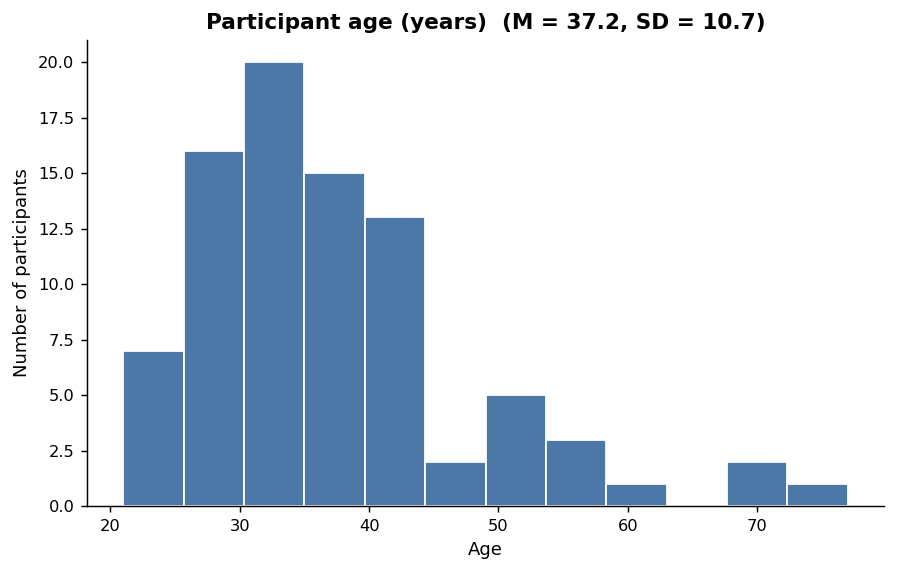

Saved: outputs/figs/fig_age.png


In [7]:
# --- Age (D1) ---
plot_continuous(df["D1"], "Participant age (years)", "fig_age.png", bins=12, xlabel="Age")


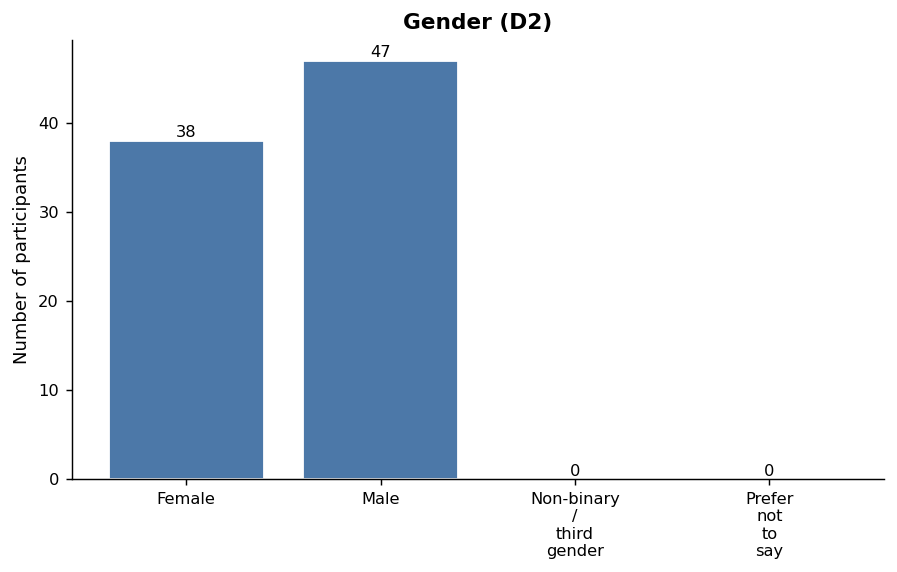

Saved: outputs/figs/fig_gender.png


In [8]:
# --- Gender (D2) ---
plot_categorical(df["D2"], "Gender (D2)", "fig_gender.png",
                 order=["Female", "Male"])


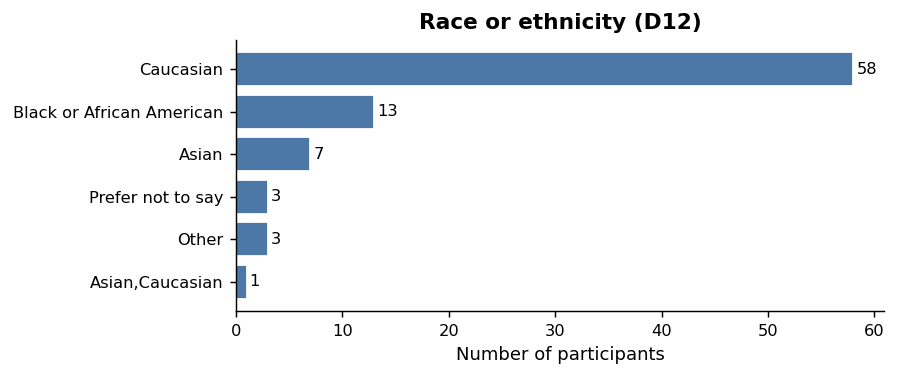

Saved: outputs/figs/fig_ethnicity.png


In [9]:
# --- Ethnicity (D12, raw) ---
plot_categorical(df["D12"], "Race or ethnicity (D12)", "fig_ethnicity.png",
                 wrap=False, horizontal=True)


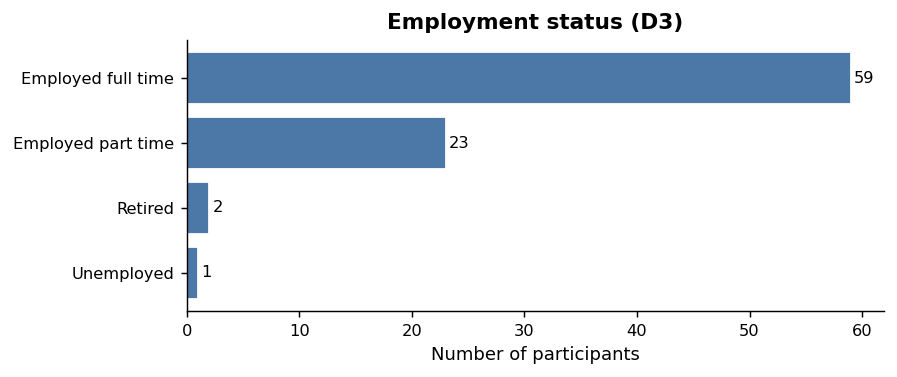

Saved: outputs/figs/fig_employment.png


In [10]:
# --- Employment status (D3) ---
plot_categorical(df["D3"], "Employment status (D3)", "fig_employment.png", wrap=False, horizontal=True)


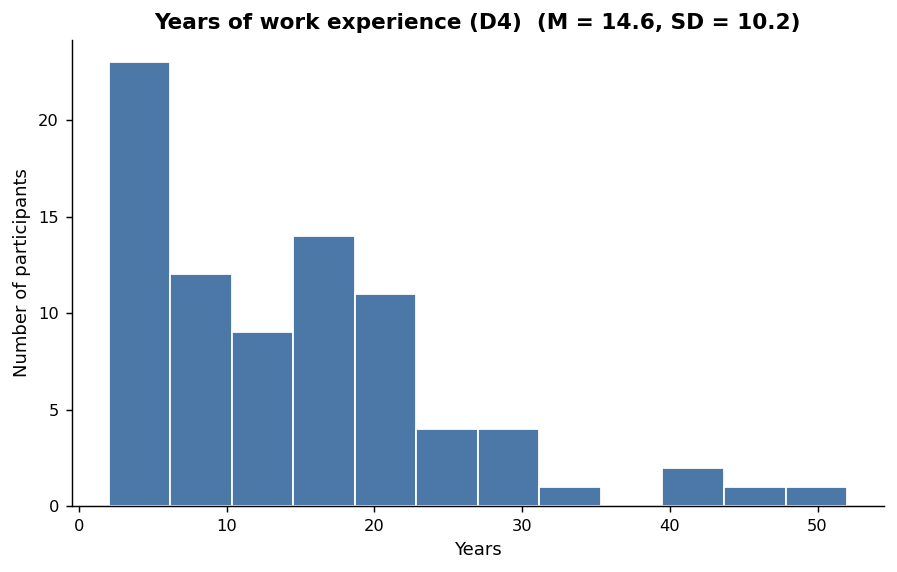

Saved: outputs/figs/fig_work_experience.png


In [11]:
# --- Years of work experience (D4) ---
plot_continuous(df["D4"], "Years of work experience (D4)", "fig_work_experience.png",
                bins=12, xlabel="Years")


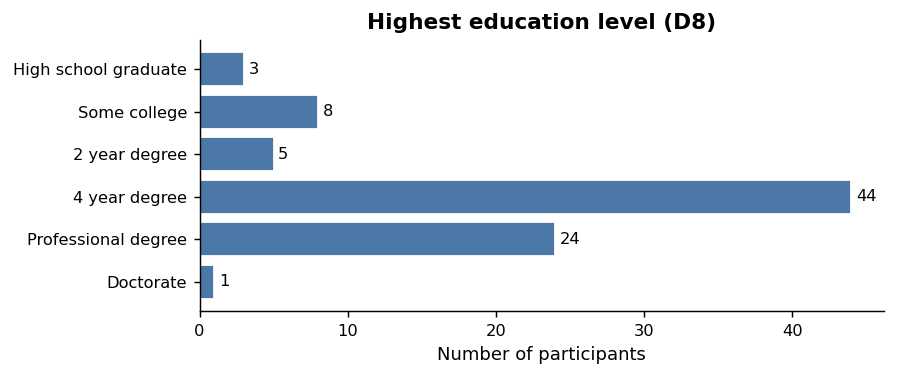

Saved: outputs/figs/fig_education.png


In [12]:
# --- Education (D8) ---
EDU_ORDER = ["High school graduate", "Some college", "2 year degree",
             "4 year degree", "Professional degree", "Doctorate"]
plot_categorical(df["D8"], "Highest education level (D8)", "fig_education.png",
                 order=EDU_ORDER, wrap=False, horizontal=True)


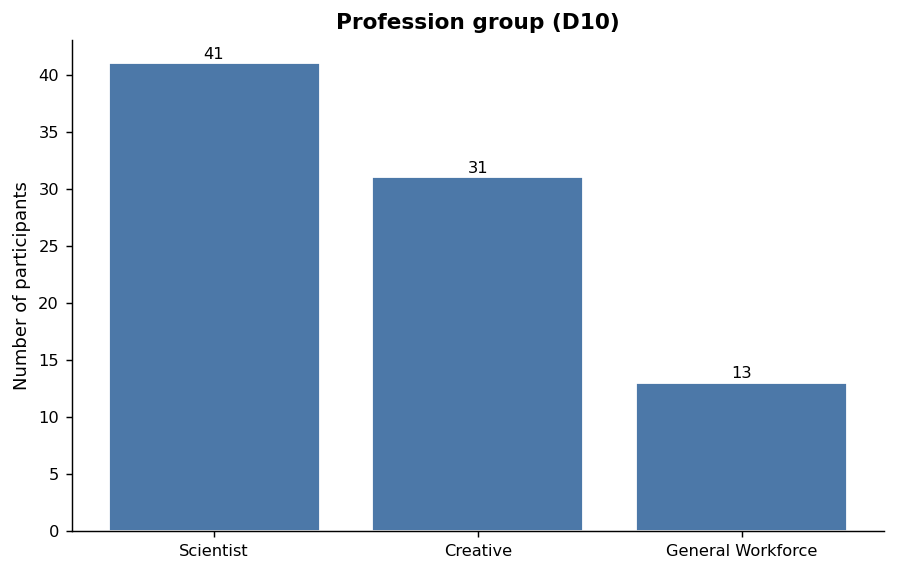

Saved: outputs/figs/fig_profession.png


In [13]:
# --- Profession bucket (D10) ---
d10_short = df["D10"].astype(str).str.split(" (", regex=False).str[0].replace({"Scientific": "Scientist"})
plot_categorical(d10_short, "Profession group (D10)", "fig_profession.png",
                 order=["Scientist", "Creative", "General Workforce"], wrap=False)


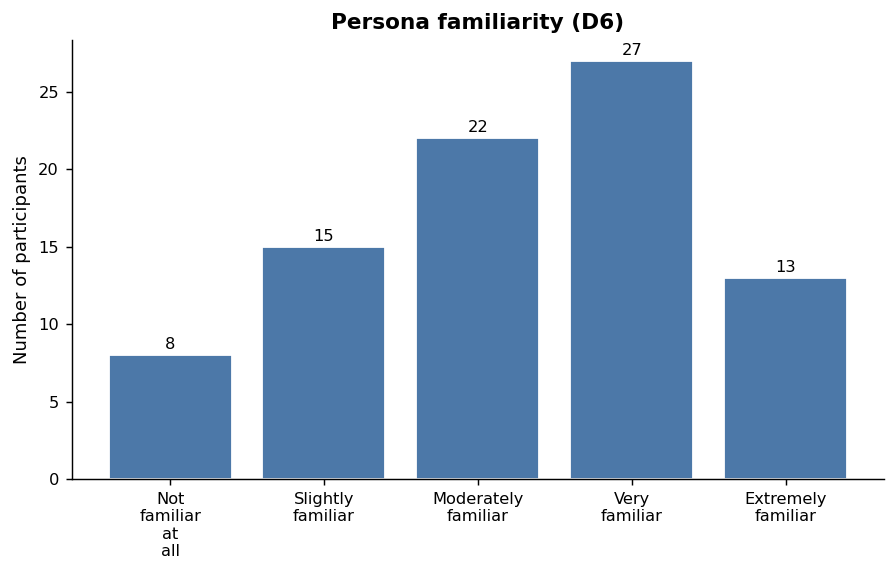

Saved: outputs/figs/fig_persona_familiarity.png


In [14]:
# --- Persona familiarity (D6) ---
D6_ORDER = ["Not familiar at all", "Slightly familiar", "Moderately familiar",
            "Very familiar", "Extremely familiar"]
plot_categorical(df["D6"], "Persona familiarity (D6)", "fig_persona_familiarity.png", order=D6_ORDER)


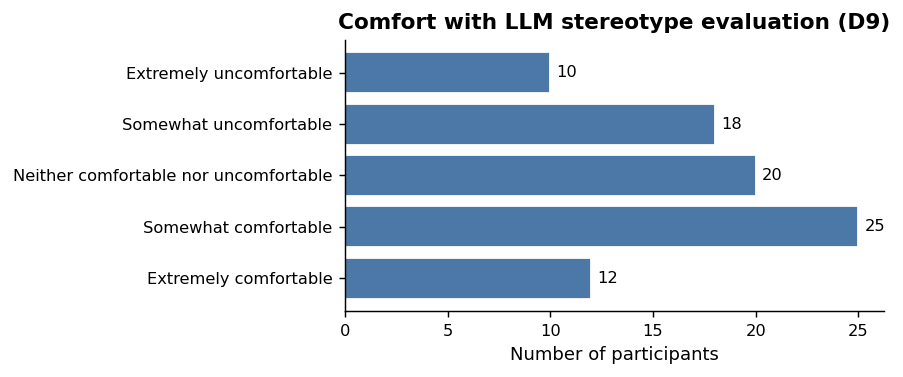

Saved: outputs/figs/fig_d9_llm_comfort.png


In [15]:
# --- Comfort with LLM stereotype evaluation (D9) ---
D9_ORDER = ["Extremely uncomfortable", "Somewhat uncomfortable",
            "Neither comfortable nor uncomfortable",
            "Somewhat comfortable", "Extremely comfortable"]
plot_categorical(df["D9"], "Comfort with LLM stereotype evaluation (D9)",
                 "fig_d9_llm_comfort.png", order=D9_ORDER, horizontal=True, wrap=False)


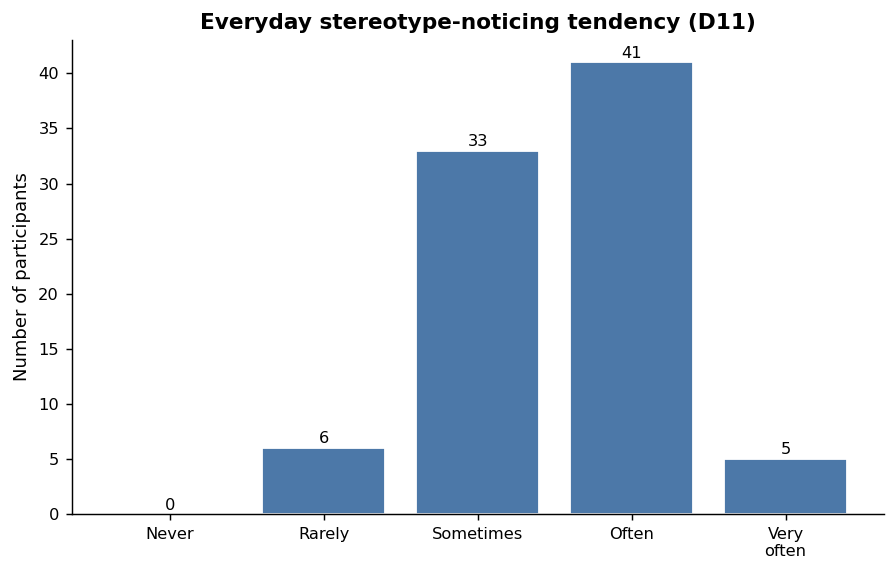

Saved: outputs/figs/fig_d11_stereotype_noticing.png


In [16]:
# --- Everyday stereotype-noticing tendency (D11) ---
D11_ORDER = ["Never", "Rarely", "Sometimes", "Often", "Very often"]
plot_categorical(df["D11"], "Everyday stereotype-noticing tendency (D11)",
                 "fig_d11_stereotype_noticing.png", order=D11_ORDER)


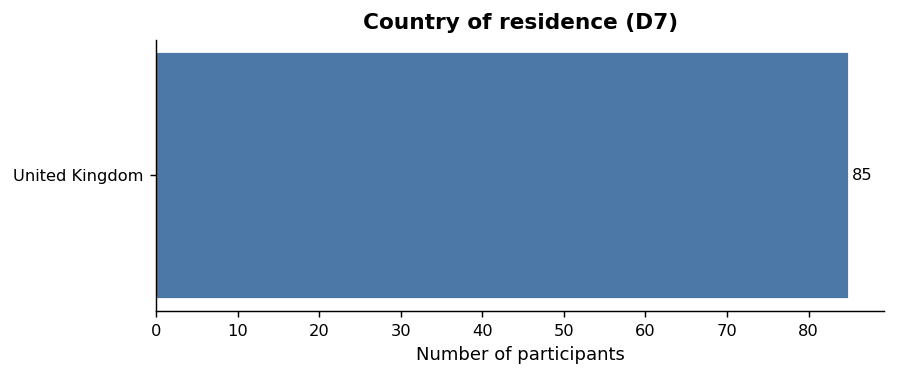

Saved: outputs/figs/fig_country.png


In [17]:
# --- Country (D7) ---
plot_categorical(df["D7"].astype(str).str.replace(
    "United Kingdom of Great Britain and Northern Ireland", "United Kingdom"),
    "Country of residence (D7)", "fig_country.png", wrap=False, horizontal=True)


In [18]:
# --- Auto-generated participant paragraph for the methods section ---
N = len(df)
age = pd.to_numeric(df["D1"], errors="coerce")
work = pd.to_numeric(df["D4"], errors="coerce")

def _pct(s, k):
    return f"{(s == k).sum()} ({(s == k).mean() * 100:.1f}%)"

def _mode(s, order):
    vc = s.dropna().value_counts()
    for x in order:
        if x in vc.index and vc[x] == vc.max():
            return x
    return vc.idxmax() if not vc.empty else "n/a"

_D6 = ["Not familiar at all", "Slightly familiar", "Moderately familiar",
       "Very familiar", "Extremely familiar"]
_D9 = ["Extremely uncomfortable", "Somewhat uncomfortable",
       "Neither comfortable nor uncomfortable",
       "Somewhat comfortable", "Extremely comfortable"]
_D11 = ["Never", "Rarely", "Sometimes", "Often", "Very often"]

d10_short = df["D10"].astype(str).str.split(" (", regex=False).str[0].replace({"Scientific": "Scientist"})

para = (
    f"A total of {N} participants were recruited via Prolific. "
    f"Ages ranged from {int(age.min())} to {int(age.max())} years (M = {age.mean():.1f}, "
    f"SD = {age.std():.1f}). The sample was {_pct(df['D2'], 'Female')} female and "
    f"{_pct(df['D2'], 'Male')} male. "
    f"Reported race or ethnicity was predominantly Caucasian "
    f"({(df['D12'] == 'Caucasian').sum()}, "
    f"{(df['D12'] == 'Caucasian').mean() * 100:.1f}%), with smaller groups identifying as Black "
    f"or African American, Asian, or mixed. "
    f"All participants ({(df['D7'].astype(str).str.contains('United Kingdom')).sum()}) reported "
    f"residence in the United Kingdom. "
    f"Employment status was mostly full-time ({_pct(df['D3'], 'Employed full time')}), with the "
    f"remainder part-time, retired, or unemployed. Years of work experience ranged from "
    f"{int(work.min())} to {int(work.max())} (M = {work.mean():.1f}, SD = {work.std():.1f}). "
    f"The most common education level was a 4-year degree "
    f"({_pct(df['D8'], '4 year degree')}), followed by a professional degree "
    f"({_pct(df['D8'], 'Professional degree')}). "
    f"Profession groups were distributed across Scientist ({_pct(d10_short, 'Scientist')}), "
    f"Creative ({_pct(d10_short, 'Creative')}), and General Workforce "
    f"({_pct(d10_short, 'General Workforce')}) roles. "
    f"On individual-difference items, modal responses were '{_mode(df['D6'], _D6)}' for "
    f"prior persona familiarity (D6), '{_mode(df['D9'], _D9)}' for comfort with LLM "
    f"stereotype evaluation (D9), and '{_mode(df['D11'], _D11)}' for self-reported "
    f"everyday stereotype-noticing tendency (D11)."
)
print(para)
(OUT_DIR / "participant_paragraph.txt").write_text(para)
print(f"\nSaved: {OUT_DIR / 'participant_paragraph.txt'}")


A total of 85 participants were recruited via Prolific. Ages ranged from 21 to 77 years (M = 37.2, SD = 10.7). The sample was 38 (44.7%) female and 47 (55.3%) male. Reported race or ethnicity was predominantly Caucasian (58, 68.2%), with smaller groups identifying as Black or African American, Asian, or mixed. All participants (85) reported residence in the United Kingdom. Employment status was mostly full-time (59 (69.4%)), with the remainder part-time, retired, or unemployed. Years of work experience ranged from 2 to 52 (M = 14.6, SD = 10.2). The most common education level was a 4-year degree (44 (51.8%)), followed by a professional degree (24 (28.2%)). Profession groups were distributed across Scientist (41 (48.2%)), Creative (31 (36.5%)), and General Workforce (13 (15.3%)) roles. On individual-difference items, modal responses were 'Very familiar' for prior persona familiarity (D6), 'Somewhat comfortable' for comfort with LLM stereotype evaluation (D9), and 'Often' for self-report

## 5. RQ1 — Manipulation check

**Hypothesis.** Yes-rate on `*_str` ("Is there something stereotypical about this persona description?") is **higher for stereotyped (`a_s_*`)** personas than for non-stereotyped (`a_us_*`) personas.

Three complementary tests, in increasing rigour:

1. **Two-proportion z-test** on aggregate counts. Treats every (rater × persona) cell as independent, which it is not, but gives an interpretable raw effect size.
2. **Wilcoxon signed-rank** on per-rater Yes-proportions (paired, 3-of-each, within-subjects).
3. **Mixed-effects logistic regression** with rater and persona random intercepts. Most defensible for write-up.


In [19]:
# Aggregate descriptives
agg = long_df.groupby("condition")["str_yes"].agg(["mean", "sum", "count"]).rename(columns={"mean": "yes_rate"})
agg["yes_rate"] = (agg["yes_rate"] * 100).round(1).astype(str) + "%"
print("Aggregate Yes-rate by condition:")
print(agg)


Aggregate Yes-rate by condition:
           yes_rate  sum  count
condition                      
non_stereo    43.1%  110    255
stereo        83.5%  213    255


In [20]:
# (1) Two-proportion z-test (one-sided: stereo > non_stereo)
y_s = long_df.loc[long_df.condition == "stereo", "str_yes"].sum()
n_s = (long_df.condition == "stereo").sum()
y_u = long_df.loc[long_df.condition == "non_stereo", "str_yes"].sum()
n_u = (long_df.condition == "non_stereo").sum()
p_pool = (y_s + y_u) / (n_s + n_u)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_s + 1 / n_u))
z_stat = (y_s / n_s - y_u / n_u) / se
p_one = 1 - stats.norm.cdf(z_stat)

print("Two-proportion z-test (one-sided: stereo > non_stereo)")
print(f"  stereo Yes:     {y_s}/{n_s} = {y_s/n_s:.3f}")
print(f"  non-stereo Yes: {y_u}/{n_u} = {y_u/n_u:.3f}")
print(f"  difference:     {y_s/n_s - y_u/n_u:+.3f}")
print(f"  z = {z_stat:.3f}, p (1-sided) = {p_one:.2e}")

print("\nAPA-style reporting sentence:")
print(f"  Pooling across all rater-by-persona ratings, stereotyped personas were flagged as")
print(f"  stereotypical more often than non-stereotyped personas ({y_s/n_s*100:.1f}% vs")
print(f"  {y_u/n_u*100:.1f}%; difference = {(y_s/n_s - y_u/n_u)*100:+.1f} percentage points),")
print(f"  z = {z_stat:.2f}, {apa_p(p_one)} (one-sided).")


Two-proportion z-test (one-sided: stereo > non_stereo)
  stereo Yes:     213/255 = 0.835
  non-stereo Yes: 110/255 = 0.431
  difference:     +0.404
  z = 9.465, p (1-sided) = 0.00e+00

APA-style reporting sentence:
  Pooling across all rater-by-persona ratings, stereotyped personas were flagged as
  stereotypical more often than non-stereotyped personas (83.5% vs
  43.1%; difference = +40.4 percentage points),
  z = 9.46, p < .001 (one-sided).


In [21]:
# (2) Wilcoxon signed-rank, per-rater paired
per_rater = (long_df
    .groupby(["pid", "condition"])["str_yes"]
    .mean()
    .unstack())
# Drop any rater missing a condition (shouldn't happen given 3+3 design)
per_rater = per_rater.dropna()

w = stats.wilcoxon(per_rater["stereo"], per_rater["non_stereo"], alternative="greater")
mdn_diff = (per_rater["stereo"] - per_rater["non_stereo"]).median()
m_diff   = (per_rater["stereo"] - per_rater["non_stereo"]).mean()
print("Wilcoxon signed-rank (paired, per-rater proportions; H1: stereo > non_stereo)")
print(f"  n raters         = {len(per_rater)}")
print(f"  mean stereo      = {per_rater['stereo'].mean():.3f}")
print(f"  mean non_stereo  = {per_rater['non_stereo'].mean():.3f}")
print(f"  mean within-pair diff = {m_diff:+.3f}")
print(f"  W = {w.statistic:.1f}, p = {w.pvalue:.2e}")

print("\nAPA-style reporting sentence:")
print(f"  A Wilcoxon signed-rank test on per-rater Yes-proportions indicated that stereotype")
print(f"  detection was higher for stereotyped than non-stereotyped personas (N = {len(per_rater)},")
print(f"  Mdn diff = {mdn_diff:+.2f}, M diff = {m_diff:+.2f}, W = {w.statistic:.1f}, {apa_p(w.pvalue)},")
print(f"  one-sided).")


Wilcoxon signed-rank (paired, per-rater proportions; H1: stereo > non_stereo)
  n raters         = 85
  mean stereo      = 0.835
  mean non_stereo  = 0.431
  mean within-pair diff = +0.404
  W = 1912.0, p = 2.12e-09

APA-style reporting sentence:
  A Wilcoxon signed-rank test on per-rater Yes-proportions indicated that stereotype
  detection was higher for stereotyped than non-stereotyped personas (N = 85,
  Mdn diff = +0.33, M diff = +0.40, W = 1912.0, p < .001,
  one-sided).


In [22]:
# (3) Mixed-effects logistic regression
# Random intercepts for rater AND persona. Crossed random effects via BinomialBayesMixedGLM
# is overkill here; use GEE-style or fit two-step. For interpretability we use
# Bayesian mixed GLM (variational) which handles crossed effects cleanly.

# Simpler and more standard: PID random intercept only (the dominant source of clustering).
md_model = smf.mixedlm(
    "str_yes ~ C(condition, Treatment(reference='non_stereo'))",
    data=long_df,
    groups=long_df["pid"],
).fit(reml=False)
print("Linear mixed model (PID random intercept) — LPM approximation:")
print(md_model.summary().tables[1])

# Pull the condition-effect row for APA reporting
_cond_key = [k for k in md_model.params.index if "stereo" in k and "Intercept" not in k][0]
b_lmm  = md_model.params[_cond_key]
se_lmm = md_model.bse[_cond_key]
z_lmm  = md_model.tvalues[_cond_key]
p_lmm  = md_model.pvalues[_cond_key]
print("\nAPA-style reporting sentence (LMM):")
print(f"  A linear mixed-effects model with rater as a random intercept showed a significant")
print(f"  effect of condition (stereotyped vs non-stereotyped) on Yes-rate, b = {b_lmm:+.2f},")
print(f"  SE = {se_lmm:.2f}, z = {z_lmm:.2f}, {apa_p(p_lmm)}.")
print()

# Proper logistic version with rater random intercept (binomial mixed)
try:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    long_df["cond_bin"] = (long_df["condition"] == "stereo").astype(int)
    bbmm = BinomialBayesMixedGLM.from_formula(
        "str_yes ~ cond_bin",
        vc_formulas={"pid": "0 + C(pid)", "persona": "0 + C(persona)"},
        data=long_df,
    ).fit_vb()
    print("Bayesian binomial mixed GLM (crossed random intercepts: PID + persona):")
    print(bbmm.summary())

    # Extract posterior mean / SD for cond_bin
    fe_names = list(bbmm.model.exog_names)
    idx_cond = fe_names.index("cond_bin")
    post_mean = float(bbmm.fe_mean[idx_cond])
    post_sd   = float(bbmm.fe_sd[idx_cond])
    or_est    = float(np.exp(post_mean))
    or_lo, or_hi = np.exp(post_mean - 1.96 * post_sd), np.exp(post_mean + 1.96 * post_sd)
    print("\nAPA-style reporting sentence (Bayesian binomial mixed GLM):")
    print(f"  A Bayesian binomial mixed-effects model with crossed random intercepts for rater")
    print(f"  and persona estimated the log-odds effect of stereotyped condition at {post_mean:+.2f}")
    print(f"  (posterior SD = {post_sd:.2f}; OR = {or_est:.2f}, 95% credible interval [{or_lo:.2f},")
    print(f"  {or_hi:.2f}]), confirming substantially higher detection probability for stereotyped")
    print(f"  personas after adjusting for rater and persona variance.")
except Exception as e:
    print("Bayesian mixed GLM skipped:", e)


Linear mixed model (PID random intercept) — LPM approximation:
                                                    Coef. Std.Err.       z  P>|z| [0.025 0.975]
Intercept                                           0.431    0.031  14.057  0.000  0.371  0.492
C(condition, Treatment(reference='non_stereo'))...  0.404    0.037  10.968  0.000  0.332  0.476
Group Var                                           0.022    0.026                             

APA-style reporting sentence (LMM):
  A linear mixed-effects model with rater as a random intercept showed a significant
  effect of condition (stereotyped vs non-stereotyped) on Yes-rate, b = +0.40,
  SE = 0.04, z = 10.97, p < .001.

Bayesian binomial mixed GLM (crossed random intercepts: PID + persona):
               Binomial Mixed GLM Results
          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------
Intercept    M    -0.3222   0.1077                      
cond_bin     M     2.1094   0.17

**Reporting note.** With Yes-rates of roughly 0.83 (stereo) vs 0.43 (non-stereo) the test passes the sense check overwhelmingly. The interesting follow-ups are *which* non-stereotyped personas attract false-positive flags (descriptive flag for the qualitative section) and whether the gap holds after adjusting for rater-level response bias.


## 6. Persona metadata for matching analyses

`PERSONA_META` below encodes each persona's gender, age band, and occupation type. Values are taken directly from the Qualtrics persona description blocks. Age uses three labels (`Young`, `Mature`, `Old`); only Ray sits in `Old`, so age-match cells involving Ray will have small N. `occupation_type` uses the same three buckets as D10 in the survey (`Scientist`, `Creative`, `General`).


In [23]:
PERSONA_META = {
    # non-stereotyped (a_us_)
    "marcus":   {"gender": "Male",   "age_band": "Young",  "occupation_type": "Creative"},
    "eleanor":  {"gender": "Female", "age_band": "Mature", "occupation_type": "Creative"},
    "mei":      {"gender": "Female", "age_band": "Young",  "occupation_type": "Scientist"},
    "marlinq":  {"gender": "Male",   "age_band": "Young",  "occupation_type": "General"},
    "richard":  {"gender": "Male",   "age_band": "Mature", "occupation_type": "Scientist"},
    "margart":  {"gender": "Female", "age_band": "Mature", "occupation_type": "General"},
    # stereotyped (a_s_)
    "bernie":   {"gender": "Male",   "age_band": "Mature", "occupation_type": "Creative"},
    "sofia":    {"gender": "Female", "age_band": "Young",  "occupation_type": "Creative"},
    "caroline": {"gender": "Female", "age_band": "Mature", "occupation_type": "Scientist"},
    "james":    {"gender": "Male",   "age_band": "Young",  "occupation_type": "Scientist"},
    "ray":      {"gender": "Male",   "age_band": "Mature",    "occupation_type": "General"},
    "aisha":    {"gender": "Female", "age_band": "Young",  "occupation_type": "General"},
}

# Re-initialize long_df to ensure a clean state before merges
def _yn_to_int(v):
    if pd.isna(v): return np.nan
    return 1 if str(v).strip().lower() == "yes" else 0

records = []
for _, r in df.iterrows():
    pid = r["PROLIFIC_PID"]
    for p in US_PERSONAS:
        v = r.get(f"a_us_{p}_str")
        if pd.notna(v):
            records.append({
                "pid": pid, "persona": p, "condition": "non_stereo",
                "str_yes": _yn_to_int(v),
                "str_typ": r.get(f"a_us_{p}_str_typ"),
                "str_typ_text": r.get(f"a_us_{p}_str_typ_4_TEXT"),
                "img_match": r.get(f"a_us_{p}_img"),
                "ass": r.get(f"a_us_{p}_ass_y"),
                "use": r.get(f"a_us_{p}_use"),
                "rel": r.get(f"a_us_{p}_rel"),
            })
    for p in S_PERSONAS:
        v = r.get(f"a_s_{p}_str")
        if pd.notna(v):
            records.append({
                "pid": pid, "persona": p, "condition": "stereo",
                "str_yes": _yn_to_int(v),
                "str_typ": r.get(f"a_s_{p}_str_typ"),
                "str_typ_text": r.get(f"a_s_{p}_str_typ_4_TEXT"),
                "img_match": r.get(f"a_s_{p}_img"),
                "ass": r.get(f"a_s_{p}_ass_y"),
                "use": r.get(f"a_s_{p}_use"),
                "rel": r.get(f"a_s_{p}_rel"),
            })
long_df = pd.DataFrame(records)

# Age binning aligned with the three persona labels (Young / Mature / Old)
def age_to_band(age):
    try:
        a = float(age)
    except Exception:
        return np.nan
    if a < 40:  return "Young"
    return "Mature"

# Build a rater attributes frame using the 'Block' column for rater_occ_type
raters = df[["PROLIFIC_PID", "D1", "D2", "Block"]].rename(columns={
    "PROLIFIC_PID": "pid",
    "D1": "rater_age",
    "D2": "rater_gender",
    "Block": "rater_occ_type", # Use Block directly for rater_occ_type
})
raters["rater_age_band"] = raters["rater_age"].apply(age_to_band)

# The _occ_bucket function and its application to rater_occ_raw are no longer needed
# as rater_occ_type is directly from 'Block'. If 'D10' (rater_occ_raw) is needed for other purposes,
# it should be included in the selection for 'raters' and handled separately.

# Merge persona meta into long_df
meta_df = (pd.DataFrame(PERSONA_META)
           .T.reset_index().rename(columns={"index": "persona",
                                            "gender": "persona_gender",
                                            "age_band": "persona_age_band",
                                            "occupation_type": "persona_occ_type"}))

long_df = long_df.merge(meta_df, on="persona", how="left").merge(raters, on="pid", how="left")

# Match flags
long_df["gender_match"] = (long_df["rater_gender"].str.lower() == long_df["persona_gender"].str.lower()).astype(int)
long_df["age_match"]    = (long_df["rater_age_band"] == long_df["persona_age_band"]).astype(int)
long_df["occ_match"]    = (long_df["rater_occ_type"] == long_df["persona_occ_type"]).astype(int)
# Mark NaN where any side is missing so we don't fake matches
for col, p_col, r_col in [("gender_match", "persona_gender", "rater_gender"),
                          ("age_match",    "persona_age_band", "rater_age_band"),
                          ("occ_match",    "persona_occ_type", "rater_occ_type")]:
    bad = long_df[p_col].isna() | long_df[r_col].isna()
    long_df.loc[bad, col] = np.nan

long_df.head()

,pid,persona,condition,str_yes,str_typ,str_typ_text,img_match,ass,use,rel,persona_gender,persona_age_band,persona_occ_type,rater_age,rater_gender,rater_occ_type,rater_age_band,gender_match,age_match,occ_match
0,6a0e0801d8ded44a65adf91e,marcus,non_stereo,1,"Age,Occupation",NaN,No,His routine hits every cliché of the modern fr...,Somewhat disagree,Somewhat agree,Male,Young,Creative,30,Male,Scientist,Young,1.0,1.0,0.0
1,6a0e0801d8ded44a65adf91e,marlinq,non_stereo,1,"Age,Gender,Occupation",NaN,No,"This is a typical age, gender and occupation r...",Strongly agree,Strongly agree,Male,Young,General,30,Male,Scientist,Young,1.0,1.0,0.0
2,6a0e0801d8ded44a65adf91e,richard,non_stereo,0,NaN,NaN,No,"He seems like a avererage person to me, I don'...",Neither agree nor disagree,Neither agree nor disagree,Male,Mature,Scientist,30,Male,Scientist,Young,1.0,0.0,1.0
3,6a0e0801d8ded44a65adf91e,bernie,stereo,1,"Age,Gender,Occupation",NaN,Yes,His description matches his persona very much....,Somewhat agree,Somewhat disagree,Male,Mature,Creative,30,Male,Scientist,Young,1.0,0.0,0.0
4,6a0e0801d8ded44a65adf91e,sofia,stereo,0,NaN,NaN,No,I don't see this as a stereotypical role or de...,Neither agree nor disagree,Somewhat disagree,Female,Young,Creative,30,Male,Scientist,Young,0.0,1.0,0.0


In [24]:
long_df.describe(include="all")

,pid,persona,condition,str_yes,str_typ,str_typ_text,img_match,ass,use,rel,persona_gender,persona_age_band,persona_occ_type,rater_age,rater_gender,rater_occ_type,rater_age_band,gender_match,age_match,occ_match
count,510,510,510,510.000000,323,42,510,510,510,510,510,510,510,510,510,510,510,510.000000,510.000000,510.000000
unique,85,12,2,NaN,15,37,2,509,5,5,2,2,3,35,2,2,2,NaN,NaN,NaN
top,6a0e0801d8ded44a65adf91e,bernie,non_stereo,NaN,Occupation,Race,No,She wasn't simplied or generalized with a group,Somewhat agree,Somewhat agree,Male,Mature,Creative,34,Male,Creative,Young,NaN,NaN,NaN
freq,6,59,255,NaN,64,6,287,2,167,143,259,284,172,42,282,276,348,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.633333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.503922,0.478431,0.323529
std,NaN,NaN,NaN,0.482368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500476,0.500025,0.468282
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
75%,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


## 7. RQ2a — Gender match between rater and persona

For each condition separately, compare Yes-rate when rater-persona gender matches vs not.


In [25]:
def _match_table(df_in, match_col, label):
    sub = df_in.dropna(subset=[match_col])
    if sub.empty:
        print(f"--- Yes-rate by {label} ---")
        print(f"  No usable rows for {match_col}. Check PERSONA_META for unresolved 'TBD' values "
              f"or unmapped rater columns.\n")
        return None
    out = (sub
        .groupby(["condition", match_col])["str_yes"]
        .agg(["mean", "sum", "count"])
        .rename(columns={"mean": "yes_rate"}))
    print(f"--- Yes-rate by {label} ---")
    print(out, "\n")
    return out

_ = _match_table(long_df, "gender_match", "gender_match")


--- Yes-rate by gender_match ---
                         yes_rate  sum  count
condition  gender_match                      
non_stereo 0.0           0.444444   56    126
           1.0           0.418605   54    129
stereo     0.0           0.842520  107    127
           1.0           0.828125  106    128 



In [26]:
# Mixed logistic, per condition: does match shift Yes-probability?
def fit_match_mixed(df_in, match_col, condition):
    sub = df_in[(df_in["condition"] == condition) & df_in[match_col].notna()].copy()
    if sub.empty or sub[match_col].nunique() < 2:
        print(f"[{condition}] skipped: insufficient variation in {match_col}\n")
        return None
    m = smf.mixedlm(f"str_yes ~ {match_col}", data=sub, groups=sub["pid"]).fit(reml=False)
    print(f"[{condition}] LMM str_yes ~ {match_col} (PID random intercept)")
    print(m.summary().tables[1])

    b  = m.params[match_col]
    se = m.bse[match_col]
    z  = m.tvalues[match_col]
    p  = m.pvalues[match_col]
    sig_phrase = "significantly predicted" if p < .05 else "did not significantly predict"
    direction  = "higher" if b > 0 else "lower"

    # Descriptive Yes-rates for the sentence
    rates = sub.groupby(match_col)["str_yes"].mean()
    yr_match = rates.get(1, np.nan) * 100
    yr_nomatch = rates.get(0, np.nan) * 100
    cond_label = "stereotyped" if condition == "stereo" else "non-stereotyped"
    feature = match_col.replace("_match", "").replace("occ", "occupation")

    print(f"\n  APA: Within {cond_label} personas, rater-persona {feature} match {sig_phrase}")
    print(f"       stereotype detection (match: {yr_match:.1f}% vs no-match: {yr_nomatch:.1f}%;")
    print(f"       b = {b:+.2f}, SE = {se:.2f}, z = {z:.2f}, {apa_p(p)}).\n")
    return m

for cond in ["stereo", "non_stereo"]:
    fit_match_mixed(long_df, "gender_match", cond)


[stereo] LMM str_yes ~ gender_match (PID random intercept)
               Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept      0.846    0.035  23.932  0.000   0.777  0.916
gender_match  -0.022    0.043  -0.515  0.607  -0.106  0.062
Group Var      0.032    0.039                              

  APA: Within stereotyped personas, rater-persona gender match did not significantly predict
       stereotype detection (match: 82.8% vs no-match: 84.3%;
       b = -0.02, SE = 0.04, z = -0.52, p = .607).

[non_stereo] LMM str_yes ~ gender_match (PID random intercept)
              Coef. Std.Err.      z  P>|z|  [0.025 0.975]
Intercept     0.431    0.048  8.993  0.000   0.337  0.525
gender_match  0.001    0.057  0.023  0.982  -0.110  0.112
Group Var     0.065    0.056                             

  APA: Within non-stereotyped personas, rater-persona gender match did not significantly predict
       stereotype detection (match: 41.9% vs no-match: 44.4%;
       b = +0.00, SE = 0.06, z = 0.02,

## 8. RQ2b — Age band match

In [27]:
_ = _match_table(long_df, "age_match", "age_match")
for cond in ["stereo", "non_stereo"]:
    fit_match_mixed(long_df, "age_match", cond)


--- Yes-rate by age_match ---
                      yes_rate  sum  count
condition  age_match                      
non_stereo 0.0        0.393939   52    132
           1.0        0.471545   58    123
stereo     0.0        0.895522  120    134
           1.0        0.768595   93    121 

[stereo] LMM str_yes ~ age_match (PID random intercept)
            Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept   0.895    0.034  26.039  0.000   0.827   0.962
age_match  -0.125    0.042  -2.954  0.003  -0.209  -0.042
Group Var   0.032    0.039                               

  APA: Within stereotyped personas, rater-persona age match significantly predicted
       stereotype detection (match: 76.9% vs no-match: 89.6%;
       b = -0.13, SE = 0.04, z = -2.95, p = .003).

[non_stereo] LMM str_yes ~ age_match (PID random intercept)
           Coef. Std.Err.      z  P>|z|  [0.025 0.975]
Intercept  0.412    0.047  8.759  0.000   0.320  0.504
age_match  0.040    0.057  0.696  0.486  -0.072  0.15

## 9. RQ2c — Occupation type match

In [28]:
_ = _match_table(long_df, "occ_match", "occ_match")
for cond in ["stereo", "non_stereo"]:
    fit_match_mixed(long_df, "occ_match", cond)


--- Yes-rate by occ_match ---
                      yes_rate  sum  count
condition  occ_match                      
non_stereo 0.0        0.440860   82    186
           1.0        0.405797   28     69
stereo     0.0        0.830189  132    159
           1.0        0.843750   81     96 

[stereo] LMM str_yes ~ occ_match (PID random intercept)
           Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept  0.831    0.033  25.538  0.000   0.768  0.895
occ_match  0.011    0.044   0.242  0.809  -0.075  0.096
Group Var  0.032    0.039                              

  APA: Within stereotyped personas, rater-persona occupation match did not significantly predict
       stereotype detection (match: 84.4% vs no-match: 83.0%;
       b = +0.01, SE = 0.04, z = 0.24, p = .809).

[non_stereo] LMM str_yes ~ occ_match (PID random intercept)
            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept   0.444    0.042  10.570  0.000   0.361  0.526
occ_match  -0.045    0.063  -0.717  0.473  -0

## 10. RQ3 — Stereotype-type attribution

`*_str_typ` is populated only when a rater answered Yes to `*_str`. Values are comma-joined subsets of {Age, Gender, Occupation, Other}. Two views:

1. **Descriptive citation profile.** Among raters who flagged a persona, which dimensions did they cite, per persona and per condition?
2. **Alignment with intended dimensions.** Each stereotyped persona was designed to stereotype along specific axes. The `INTENDED_DIMS` config below encodes those; the alignment score is the proportion of cited dimensions that overlap with the intended set.


In [29]:
# Parse comma-joined str_typ into four binary indicators (NaN if rater said No to _str)
def _parse_dims(s):
    if pd.isna(s):
        return set()
    return {t.strip() for t in str(s).split(",") if t.strip()}

for dim in ["Age", "Gender", "Occupation", "Other"]:
    col = f"cited_{dim.lower()}"
    long_df[col] = long_df["str_typ"].apply(
        lambda s: 1 if dim in _parse_dims(s) else (0 if pd.notna(s) else np.nan)
    )
    # If rater said Yes but typ is empty, leave the 0 in place (rare); if str_yes==0, force NaN
    long_df.loc[long_df["str_yes"] == 0, col] = np.nan

dim_cols = ["cited_age", "cited_gender", "cited_occupation", "cited_other"]

print("Citation rates among flaggers (str_yes == 1), by condition:")
print(long_df[long_df["str_yes"] == 1].groupby("condition")[dim_cols].mean().round(3))


Citation rates among flaggers (str_yes == 1), by condition:
            cited_age  cited_gender  cited_occupation  cited_other
condition                                                         
non_stereo      0.518         0.336             0.791        0.136
stereo          0.629         0.474             0.484        0.127


In [30]:
# Per-persona citation profile (only among flaggers)
flagged = long_df[long_df["str_yes"] == 1].copy()
persona_profile = (flagged
    .groupby(["condition", "persona"])[dim_cols]
    .mean()
    .round(2))
print("Per-persona citation profile (proportion of flaggers citing each dimension):")
print(persona_profile)


Per-persona citation profile (proportion of flaggers citing each dimension):
                     cited_age  cited_gender  cited_occupation  cited_other
condition  persona                                                         
non_stereo eleanor        0.30          0.10              0.70         0.30
           marcus         0.54          0.23              0.92         0.08
           margart        0.88          0.76              0.59         0.12
           marlinq        0.41          0.32              0.86         0.16
           mei            0.11          0.33              0.78         0.22
           richard        0.67          0.21              0.79         0.04
stereo     aisha          0.55          0.77              0.36         0.50
           bernie         0.93          0.20              0.36         0.05
           caroline       0.50          0.94              0.33         0.02
           james          0.22          0.17              0.94         0.22
           

In [31]:
# RQ3 alignment with intended stereotype dimensions
# Edit INTENDED_DIMS to reflect the actual design intent for each stereotyped persona.
INTENDED_DIMS = {
    "bernie":   {"Age", "Occupation"},        # old-school architect refusing tech
    "sofia":    {"Gender", "Age", "Occupation"},  # emotional young female creative
    "caroline": {"Gender", "Age"},            # deferring older woman scientist
    "james":    {"Occupation", "Gender"},     # arrogant young male academic
    "ray":      {"Age", "Gender"},            # tech-refusing older man
    "aisha":    {"Gender", "Age"},            # submissive young woman
}

def _alignment(row):
    if row["str_yes"] != 1 or row["condition"] != "stereo":
        return np.nan
    intended = INTENDED_DIMS.get(row["persona"], set())
    cited = _parse_dims(row["str_typ"]) - {"Other"}
    if not intended or not cited:
        return np.nan
    return len(intended & cited) / len(intended | cited)  # Jaccard

long_df["alignment_jaccard"] = long_df.apply(_alignment, axis=1)
align_summary = long_df.groupby("persona")["alignment_jaccard"].agg(["mean", "count"]).dropna().round(3)
print("Cited-vs-intended Jaccard alignment per stereotyped persona:")
print(align_summary)

# Chi-square: do cited-dimension distributions differ by condition?
ctab = (long_df[long_df["str_yes"] == 1]
        .groupby("condition")[["cited_age", "cited_gender", "cited_occupation"]]
        .sum())
chi2, p_chi, dof, exp = stats.chi2_contingency(ctab.values)
print(f"\nChi-square (condition x cited-dimension counts): chi2 = {chi2:.2f}, dof = {dof}, {apa_p(p_chi)}")
print("\nAPA-style reporting sentence:")
print(f"  The distribution of stereotype dimensions cited by flaggers differed across conditions,")
print(f"  chi2({dof}) = {chi2:.2f}, {apa_p(p_chi)}. Mean Jaccard alignment between cited and")
print(f"  intended dimensions across stereotyped personas was {align_summary['mean'].mean():.2f}.")


Cited-vs-intended Jaccard alignment per stereotyped persona:
           mean  count
persona               
aisha     0.658     19
bernie    0.611     54
caroline  0.642     48
james     0.529     17
ray       0.653     25
sofia     0.585     41

Chi-square (condition x cited-dimension counts): chi2 = 16.05, dof = 2, p < .001

APA-style reporting sentence:
  The distribution of stereotype dimensions cited by flaggers differed across conditions,
  chi2(2) = 16.05, p < .001. Mean Jaccard alignment between cited and
  intended dimensions across stereotyped personas was 0.61.


## 11. RQ4 — Trade-offs with usefulness and relatability

`_use` ("This persona helped me understand this group of people") and `_rel` ("I find this persona relatable") are 5-point Likert items. Qualtrics stored them with codes 8-12; recoded to 1-5 below. Two complementary questions:

(a) Do mean usefulness/relatability scores differ between stereotyped and non-stereotyped personas?
(b) Within each condition, does flagging a persona as stereotyped predict lower (or higher) usefulness/relatability?


In [32]:
# Recode Likert labels to 1-5 numeric
LIKERT = {
    "Strongly disagree": 1, "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4, "Strongly agree": 5,
}
long_df["use_num"] = long_df["use"].map(LIKERT)
long_df["rel_num"] = long_df["rel"].map(LIKERT)

print("Means by condition:")
print(long_df.groupby("condition")[["use_num", "rel_num"]].agg(["mean", "std", "count"]).round(2))


Means by condition:
           use_num             rel_num            
              mean   std count    mean   std count
condition                                         
non_stereo    3.60  1.03   255    3.53  1.18   255
stereo        2.64  1.27   255    2.31  1.30   255


In [33]:
# (a) Between-condition: use/rel ~ condition
for dv in ["use_num", "rel_num"]:
    m = smf.mixedlm(f"{dv} ~ C(condition, Treatment(reference='non_stereo'))",
                    data=long_df.dropna(subset=[dv]),
                    groups=long_df.dropna(subset=[dv])["pid"]).fit(reml=False)
    key = [k for k in m.params.index if "stereo" in k and "Intercept" not in k][0]
    b, se, z, p = m.params[key], m.bse[key], m.tvalues[key], m.pvalues[key]
    direction = "lower" if b < 0 else "higher"
    sig = "a significant" if p < .05 else "no significant"
    label = "usefulness" if dv == "use_num" else "relatability"
    print(f"\n[{dv}] LMM {dv} ~ condition")
    print(m.summary().tables[1])
    print(f"  APA: Stereotyped personas were rated {direction} on {label} than non-stereotyped")
    print(f"       personas, with {sig} difference, b = {b:+.2f}, SE = {se:.2f}, z = {z:.2f},")
    print(f"       {apa_p(p)}.")



[use_num] LMM use_num ~ condition
                                                     Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                                            3.604    0.095   37.941  0.000   3.418   3.790
C(condition, Treatment(reference='non_stereo'))...  -0.965    0.082  -11.781  0.000  -1.125  -0.804
Group Var                                            0.482    0.113                                
  APA: Stereotyped personas were rated lower on usefulness than non-stereotyped
       personas, with a significant difference, b = -0.96, SE = 0.08, z = -11.78,
       p < .001.

[rel_num] LMM rel_num ~ condition
                                                     Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                                            3.533    0.096   36.921  0.000   3.346   3.721
C(condition, Treatment(reference='non_stereo'))...  -1.227    0.094  -13.032  0.000  -1.412  -1.043
Group Var                                          

In [34]:
# (b) Within-condition: does flagging the persona predict lower use/rel?
for cond in ["stereo", "non_stereo"]:
    sub = long_df[long_df["condition"] == cond].copy()
    for dv in ["use_num", "rel_num"]:
        ss = sub.dropna(subset=[dv, "str_yes"])
        m = smf.mixedlm(f"{dv} ~ str_yes", data=ss, groups=ss["pid"]).fit(reml=False)
        b, se, z, p = m.params["str_yes"], m.bse["str_yes"], m.tvalues["str_yes"], m.pvalues["str_yes"]
        direction = "lower" if b < 0 else "higher"
        sig = "significantly" if p < .05 else "did not significantly"
        label = "usefulness" if dv == "use_num" else "relatability"
        print(f"  APA [{cond}]: Within {cond} personas, flagging a stereotype predicted {direction}")
        print(f"               perceived {label}, b = {b:+.2f}, SE = {se:.2f}, z = {z:.2f},")
        print(f"               {apa_p(p)} ({sig}).")


  APA [stereo]: Within stereo personas, flagging a stereotype predicted higher
               perceived usefulness, b = +0.23, SE = 0.20, z = 1.14,
               p = .254 (did not significantly).
  APA [stereo]: Within stereo personas, flagging a stereotype predicted higher
               perceived relatability, b = +0.37, SE = 0.20, z = 1.81,
               p = .071 (did not significantly).
  APA [non_stereo]: Within non_stereo personas, flagging a stereotype predicted lower
               perceived usefulness, b = -0.18, SE = 0.12, z = -1.57,
               p = .116 (did not significantly).
  APA [non_stereo]: Within non_stereo personas, flagging a stereotype predicted lower
               perceived relatability, b = -0.19, SE = 0.15, z = -1.30,
               p = .192 (did not significantly).


## 12. RQ5 — Individual difference moderators (D9, D11)

D11 ("In your everyday life, how often do you notice stereotypes...") and D9 ("How comfortable are you with LLMs evaluating stereotypes...") are 5-point ordinal items. Recoded to numeric below. Each is tested as a moderator of the condition effect:

`str_yes ~ condition * predictor + (1 | pid) + (1 | persona)`

If D11 predicts higher Yes-rate within stereotyped but not within non-stereotyped, it has discriminant validity. If D11 raises Yes-rate uniformly, that is response style, not stereotype-noticing ability.


In [35]:
D11_MAP = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Very often": 5}
D9_MAP  = {"Extremely uncomfortable": 1, "Somewhat uncomfortable": 2,
           "Neither comfortable nor uncomfortable": 3,
           "Somewhat comfortable": 4, "Extremely comfortable": 5}

# Merge from df (rater-level) into long_df
ind_df = df[["PROLIFIC_PID", "D9", "D11"]].rename(columns={"PROLIFIC_PID": "pid"})
ind_df["D9_score"]  = ind_df["D9"].map(D9_MAP)
ind_df["D11_score"] = ind_df["D11"].map(D11_MAP)
long_df = long_df.merge(ind_df[["pid", "D9_score", "D11_score"]], on="pid", how="left")

print("D11 distribution:", long_df.drop_duplicates("pid")["D11_score"].value_counts(dropna=False).to_dict())
print("D9 distribution: ", long_df.drop_duplicates("pid")["D9_score"].value_counts(dropna=False).to_dict())


D11 distribution: {4: 41, 3: 33, 2: 6, 5: 5}
D9 distribution:  {4: 25, 3: 20, 2: 18, 5: 12, 1: 10}


In [36]:
# RQ5: condition x D11_score
ss = long_df.dropna(subset=["D11_score", "str_yes"]).copy()
ss["cond_bin"] = (ss["condition"] == "stereo").astype(int)
m = smf.mixedlm("str_yes ~ cond_bin * D11_score", data=ss, groups=ss["pid"]).fit(reml=False)
print("LMM str_yes ~ condition * D11_score (PID random intercept)")
print(m.summary().tables[1])

for key in ["D11_score", "cond_bin:D11_score"]:
    b, se, z, p = m.params[key], m.bse[key], m.tvalues[key], m.pvalues[key]
    sig = "significantly" if p < .05 else "did not significantly"
    if key == "D11_score":
        print(f"\n  APA: Self-reported stereotype-noticing tendency (D11) {sig} predicted Yes-rate")
        print(f"       in the non-stereotyped baseline, b = {b:+.3f}, SE = {se:.3f}, z = {z:.2f},")
        print(f"       {apa_p(p)}.")
    else:
        print(f"  APA: The condition x D11 interaction was {'significant' if p < .05 else 'non-significant'},")
        print(f"       b = {b:+.3f}, SE = {se:.3f}, z = {z:.2f}, {apa_p(p)}, indicating that")
        print(f"       D11 {'did' if p < .05 else 'did not'} differentially track Yes-rate in the stereotyped condition.")


LMM str_yes ~ condition * D11_score (PID random intercept)
                     Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept            0.383    0.155   2.476  0.013   0.080  0.687
cond_bin             0.527    0.186   2.835  0.005   0.163  0.892
D11_score            0.014    0.043   0.317  0.751  -0.071  0.098
cond_bin:D11_score  -0.035    0.052  -0.677  0.498  -0.136  0.066
Group Var            0.022    0.025                              

  APA: Self-reported stereotype-noticing tendency (D11) did not significantly predicted Yes-rate
       in the non-stereotyped baseline, b = +0.014, SE = 0.043, z = 0.32,
       p = .751.
  APA: The condition x D11 interaction was non-significant,
       b = -0.035, SE = 0.052, z = -0.68, p = .498, indicating that
       D11 did not differentially track Yes-rate in the stereotyped condition.


In [37]:
# RQ5: condition x D9_score
ss = long_df.dropna(subset=["D9_score", "str_yes"]).copy()
ss["cond_bin"] = (ss["condition"] == "stereo").astype(int)
m = smf.mixedlm("str_yes ~ cond_bin * D9_score", data=ss, groups=ss["pid"]).fit(reml=False)
print("LMM str_yes ~ condition * D9_score (PID random intercept)")
print(m.summary().tables[1])

for key in ["D9_score", "cond_bin:D9_score"]:
    b, se, z, p = m.params[key], m.bse[key], m.tvalues[key], m.pvalues[key]
    sig = "significantly" if p < .05 else "did not significantly"
    if key == "D9_score":
        print(f"\n  APA: Comfort with LLM stereotype evaluation (D9) {sig} predicted Yes-rate")
        print(f"       in the non-stereotyped baseline, b = {b:+.3f}, SE = {se:.3f}, z = {z:.2f},")
        print(f"       {apa_p(p)}.")
    else:
        print(f"  APA: The condition x D9 interaction was {'significant' if p < .05 else 'non-significant'},")
        print(f"       b = {b:+.3f}, SE = {se:.3f}, z = {z:.2f}, {apa_p(p)}.")


LMM str_yes ~ condition * D9_score (PID random intercept)
                    Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept           0.280    0.081   3.456  0.001   0.121   0.439
cond_bin            0.672    0.100   6.710  0.000   0.476   0.869
D9_score            0.048    0.024   2.002  0.045   0.001   0.096
cond_bin:D9_score  -0.086    0.030  -2.879  0.004  -0.144  -0.027
Group Var           0.018    0.021                               

  APA: Comfort with LLM stereotype evaluation (D9) significantly predicted Yes-rate
       in the non-stereotyped baseline, b = +0.048, SE = 0.024, z = 2.00,
       p = .045.
  APA: The condition x D9 interaction was significant,
       b = -0.086, SE = 0.030, z = -2.88, p = .004.


## 13. RQ6 — Unpacking the RQ2b age-match attenuation

The headline RQ2b finding (age match associated with *lower* stereotype detection within stereo) needs three diagnostic cuts before going into a paper.

(a) **Interaction with age band.** Is the attenuation uniform, or driven by one band?
(b) **Per-persona breakdown.** Within stereo, is the effect concentrated on one or two personas?
(c) **Response-bias adjustment.** After controlling for each rater's baseline (non-stereo) Yes-rate, does the age-match coefficient survive?


In [38]:
# (a) age_match x age_band interaction within stereo
ss = long_df[(long_df["condition"] == "stereo") &
             long_df["age_match"].notna() &
             long_df["persona_age_band"].notna()].copy()

m = smf.mixedlm("str_yes ~ age_match * C(persona_age_band)",
                data=ss, groups=ss["pid"]).fit(reml=False)
print("LMM str_yes ~ age_match * persona_age_band (stereo only, PID random intercept)")
print(m.summary().tables[1])

print("\nMarginal Yes-rates within stereo, by persona age band x match:")
print(ss.groupby(["persona_age_band", "age_match"])["str_yes"].agg(["mean", "count"]).round(3))


LMM str_yes ~ age_match * persona_age_band (stereo only, PID random intercept)
                                         Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                0.895    0.039  22.777  0.000   0.818   0.972
C(persona_age_band)[T.Young]            -0.005    0.074  -0.066  0.948  -0.149   0.140
age_match                                0.038    0.070   0.542  0.588  -0.099   0.174
age_match:C(persona_age_band)[T.Young]  -0.252    0.115  -2.187  0.029  -0.479  -0.026
Group Var                                0.028    0.037                               

Marginal Yes-rates within stereo, by persona age band x match:
                             mean  count
persona_age_band age_match              
Mature           0.0        0.898     98
                 1.0        0.933     45
Young            0.0        0.889     36
                 1.0        0.671     76


In [39]:
# (b) Per-persona age-match effect within stereo
print("Per-persona Yes-rate by age_match (stereo personas only):")
for p in ["bernie", "sofia", "caroline", "james", "ray", "aisha"]:
    sub = long_df[(long_df["persona"] == p) & long_df["age_match"].notna()]
    if sub["age_match"].nunique() < 2:
        print(f"  {p:9s}: insufficient match variation (rater pool homogeneous on age band)")
        continue
    rates = sub.groupby("age_match")["str_yes"].agg(["mean", "count"]).round(3)
    diff = rates.loc[1, "mean"] - rates.loc[0, "mean"] if 1 in rates.index and 0 in rates.index else np.nan
    print(f"  {p:9s}: no-match {rates.loc[0,'mean']:.2f} (n={rates.loc[0,'count']}), "
          f"match {rates.loc[1,'mean']:.2f} (n={rates.loc[1,'count']}), diff = {diff:+.2f}")


Per-persona Yes-rate by age_match (stereo personas only):
  bernie   : no-match 0.93 (n=42), match 0.94 (n=17), diff = +0.01
  sofia    : no-match 0.90 (n=20), match 0.69 (n=36), diff = -0.21
  caroline : no-match 0.87 (n=38), match 0.88 (n=17), diff = +0.01
  james    : no-match 0.75 (n=8), match 0.60 (n=20), diff = -0.15
  ray      : no-match 0.89 (n=18), match 1.00 (n=11), diff = +0.11
  aisha    : no-match 1.00 (n=8), match 0.70 (n=20), diff = -0.30


In [40]:
# (c) Response-bias adjustment: each rater's baseline (non-stereo) Yes-rate as covariate
baseline = (long_df[long_df["condition"] == "non_stereo"]
            .groupby("pid")["str_yes"].mean()
            .rename("baseline_yes")
            .reset_index())
long_df = long_df.merge(baseline, on="pid", how="left")

ss = long_df[(long_df["condition"] == "stereo") &
             long_df["age_match"].notna() &
             long_df["baseline_yes"].notna()].copy()
m = smf.mixedlm("str_yes ~ age_match + baseline_yes",
                data=ss, groups=ss["pid"]).fit(reml=False)
print("LMM str_yes ~ age_match + baseline_yes (stereo only, PID random intercept)")
print(m.summary().tables[1])

b, se, z, p = m.params["age_match"], m.bse["age_match"], m.tvalues["age_match"], m.pvalues["age_match"]
sig = "remained significant" if p < .05 else "no longer reached significance"
print(f"\n  APA: After adjusting for each rater's baseline (non-stereo) Yes-rate, the age-match")
print(f"       coefficient {sig}, b = {b:+.2f}, SE = {se:.2f}, z = {z:.2f}, {apa_p(p)}.")


LMM str_yes ~ age_match + baseline_yes (stereo only, PID random intercept)
               Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept      0.935    0.048  19.434  0.000   0.841   1.029
age_match     -0.126    0.042  -2.968  0.003  -0.209  -0.043
baseline_yes  -0.092    0.078  -1.184  0.236  -0.246   0.061
Group Var      0.031    0.038                               

  APA: After adjusting for each rater's baseline (non-stereo) Yes-rate, the age-match
       coefficient remained significant, b = -0.13, SE = 0.04, z = -2.97, p = .003.


In [41]:
## Age × gender matching analysis

def fit_age_gender_match_interaction(df_in, condition):
    sub = df_in[
        (df_in["condition"] == condition) &
        df_in["age_match"].notna() &
        df_in["gender_match"].notna()
    ].copy()

    print(f"\n=== {condition}: age_match × gender_match ===")
    print(
        sub.groupby(["age_match", "gender_match"])["str_yes"]
        .agg(["mean", "sum", "count"])
        .round(3)
    )

    m = smf.mixedlm(
        "str_yes ~ age_match * gender_match",
        data=sub,
        groups=sub["pid"]
    ).fit(reml=False)

    print(m.summary().tables[1])

    for key in ["age_match", "gender_match", "age_match:gender_match"]:
        b, se, z, p = m.params[key], m.bse[key], m.tvalues[key], m.pvalues[key]
        print(f"{key}: b = {b:+.2f}, SE = {se:.2f}, z = {z:.2f}, {apa_p(p)}")

    return m

m_stereo_age_gender = fit_age_gender_match_interaction(long_df, "stereo")
m_nonstereo_age_gender = fit_age_gender_match_interaction(long_df, "non_stereo")


## Focused check: young stereotyped female personas only

young_female_stereo = long_df[
    (long_df["condition"] == "stereo") &
    (long_df["persona"].isin(["sofia", "aisha"]))
].copy()

print("\n=== Sofia + Aisha only: age_match × gender_match ===")
print(
    young_female_stereo.groupby(["age_match", "gender_match"])["str_yes"]
    .agg(["mean", "sum", "count"])
    .round(3)
)

m_sofia_aisha = smf.mixedlm(
    "str_yes ~ age_match * gender_match",
    data=young_female_stereo,
    groups=young_female_stereo["pid"]
).fit(reml=False)

print(m_sofia_aisha.summary().tables[1])


=== stereo: age_match × gender_match ===
                         mean  sum  count
age_match gender_match                   
0.0       0.0           0.924   61     66
          1.0           0.868   59     68
1.0       0.0           0.754   46     61
          1.0           0.783   47     60
                         Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                0.922    0.045  20.414  0.000   0.833   1.010
age_match               -0.158    0.061  -2.613  0.009  -0.277  -0.040
gender_match            -0.054    0.058  -0.917  0.359  -0.168   0.061
age_match:gender_match   0.066    0.087   0.758  0.448  -0.105   0.237
Group Var                0.032    0.039                               
age_match: b = -0.16, SE = 0.06, z = -2.61, p = .009
gender_match: b = -0.05, SE = 0.06, z = -0.92, p = .359
age_match:gender_match: b = +0.07, SE = 0.09, z = 0.76, p = .448

=== non_stereo: age_match × gender_match ===
                         mean  sum  count
age_match gender_m

## 14. RQ7 — Image vs description congruence

`*_img` asks whether the persona's *image* contains a stereotype. `*_str` asks the same of the description. RQ7 tests whether the two modalities track each other, both at the aggregate level (RQ1-style sense check on `img_yes`) and within each (rater × persona) pairing (do raters who flag the description also flag the image?).


In [42]:
# Build img_yes column on the same long frame
long_df["img_yes"] = long_df["img_match"].map({"Yes": 1, "No": 0})

print("img_yes rate by condition:")
print(long_df.groupby("condition")["img_yes"].agg(["mean", "sum", "count"]).round(3))

# Sense check parallel to RQ1, two-sided since the direction is not guaranteed
yi_s = long_df.loc[long_df.condition == "stereo", "img_yes"].sum()
ni_s = long_df.loc[long_df.condition == "stereo", "img_yes"].notna().sum()
yi_u = long_df.loc[long_df.condition == "non_stereo", "img_yes"].sum()
ni_u = long_df.loc[long_df.condition == "non_stereo", "img_yes"].notna().sum()
pp = (yi_s + yi_u) / (ni_s + ni_u)
se_i = np.sqrt(pp * (1 - pp) * (1/ni_s + 1/ni_u))
zi = (yi_s/ni_s - yi_u/ni_u) / se_i
pi_two = 2 * (1 - stats.norm.cdf(abs(zi)))
direction = "higher" if zi > 0 else "lower"
print(f"\nTwo-proportion z (img_yes, two-sided): z = {zi:.2f}, {apa_p(pi_two)}")
print(f"  stereo:     {yi_s/ni_s*100:.1f}%   non-stereo: {yi_u/ni_u*100:.1f}%")
print(f"\n  APA: Image Yes-rate was {direction} for stereotyped than non-stereotyped personas")
print(f"       ({yi_s/ni_s*100:.1f}% vs {yi_u/ni_u*100:.1f}%), z = {zi:.2f}, {apa_p(pi_two)} (two-sided),")
print(f"       a pattern that runs counter to the description-based RQ1 result and warrants")
print(f"       inspection of image stimulus selection per condition.")


img_yes rate by condition:
             mean  sum  count
condition                    
non_stereo  0.510  130    255
stereo      0.365   93    255

Two-proportion z (img_yes, two-sided): z = -3.30, p < .001
  stereo:     36.5%   non-stereo: 51.0%

  APA: Image Yes-rate was lower for stereotyped than non-stereotyped personas
       (36.5% vs 51.0%), z = -3.30, p < .001 (two-sided),
       a pattern that runs counter to the description-based RQ1 result and warrants
       inspection of image stimulus selection per condition.


In [43]:
# Within (rater x persona), does img_yes track str_yes?
both = long_df.dropna(subset=["img_yes", "str_yes"]).copy()
ct = pd.crosstab(both["img_yes"], both["str_yes"], margins=True)
print("img_yes x str_yes cross-tab (all rows):")
print(ct)

# Phi / Cramer's V from chi-square
chi2, p_chi, dof, _ = stats.chi2_contingency(ct.iloc[:-1, :-1].values)
phi = np.sqrt(chi2 / len(both))
print(f"\nchi2({dof}) = {chi2:.2f}, {apa_p(p_chi)}, phi = {phi:.2f}")

# Mixed model: predict img_yes from str_yes, controlling for condition and persona
m = smf.mixedlm("img_yes ~ str_yes + C(condition, Treatment(reference='non_stereo'))",
                data=both, groups=both["pid"]).fit(reml=False)
print("\nLMM img_yes ~ str_yes + condition (PID random intercept)")
print(m.summary().tables[1])
b, se, z, p = m.params["str_yes"], m.bse["str_yes"], m.tvalues["str_yes"], m.pvalues["str_yes"]
sig = "significantly" if p < .05 else "did not significantly"
print(f"\n  APA: Flagging the description as stereotyped {sig} predicted flagging the image as")
print(f"       stereotyped, controlling for condition, b = {b:+.2f}, SE = {se:.2f}, z = {z:.2f},")
print(f"       {apa_p(p)} (phi between the two binary judgments = {phi:.2f}).")


img_yes x str_yes cross-tab (all rows):
str_yes    0    1  All
img_yes               
0        131  156  287
1         56  167  223
All      187  323  510

chi2(1) = 21.91, p < .001, phi = 0.21

LMM img_yes ~ str_yes + condition (PID random intercept)
                                                     Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                            0.387    0.039   9.821  0.000   0.310   0.464
C(condition, Treatment(reference='non_stereo'))...  -0.260    0.042  -6.127  0.000  -0.343  -0.177
str_yes                                              0.285    0.047   6.040  0.000   0.192   0.377
Group Var                                            0.036    0.027                               

  APA: Flagging the description as stereotyped significantly predicted flagging the image as
       stereotyped, controlling for condition, b = +0.28, SE = 0.05, z = 6.04,
       p < .001 (phi between the two binary judgments = 0.21).


## 15. Open follow-up analyses

What is *not yet* implemented above and would still strengthen the paper:

**A. Per-persona detectability ranking.** True-positive rate (Yes-rate) for each stereotyped persona and false-positive rate for each non-stereotyped persona, sorted. Surfaces which personas were "obviously" stereotyped and which non-stereotyped personas read as stereotypical anyway. `marlinq` Yes-rate above 50 percent is the obvious candidate to inspect.

**B. Open-text qualitative coding.** `*_str_y` (free text "what about the persona description appears stereotype to you") and `*_str_typ_4_TEXT` ("Other" elaborations). Thematic coding validates the closed-form categories used in RQ3.

**C. Inter-rater agreement per persona.** Fleiss' kappa or simple percent-agreement on the `*_str` item for each persona, to surface which personas have stable vs contested stereotypicality judgments.

**D. Intersectional matching.** Two-way and three-way interactions of gender_match x age_match x occ_match within each condition. Powered for main effects but worth descriptive reporting.

**E. Rater race/ethnicity (D12) and persona ethnicity.** If `PERSONA_META` is extended with an ethnicity field, in-group versus out-group detection patterns become testable, which is one of the more publishable angles given current discourse on persona stereotyping.

**F. Familiarity and prior-AI exposure.** D6 (persona familiarity) is the obvious next moderator after D9 and D11. Worth a quick check.


In [44]:
 # ==================== RQ8: Ethnicity match + group-specific stereo detection ====================

# 1) Persona ethnicity from your design intent
PERSONA_ETHNICITY = {
    "marcus":   "Mixed",   # Marcus Lindquist
    "eleanor":  "Black",
    "mei":      "Asian",
    "marlinq":  "Caucasian",   # Marcus Lindquist (if the alt-name slug refers to him)
    "richard":  "Caucasian",       # if Richard is the "Marcus Chen" you meant, change to "Mixed"
    "margart":  "Mixed",       # Margaret
    "bernie":   "Caucasian",
    "sofia":    "Mixed",
    "caroline": "Caucasian",
    "james":    "Black",
    "ray":      "Caucasian",
    "aisha":    "Asian",
}

# 2) Pull rater ethnicity from ethnicity_check (new column) with D12 fallback
def _rater_eth(row):
    v = row.get("Ethnicity_Check")
    if pd.notna(v) and str(v).strip():
        return str(v).strip()
    # Fallback for older exports
    d12 = row.get("D12")
    if pd.isna(d12):
        return np.nan
    s = str(d12).strip()
    other = row.get("D12_12_TEXT")
    if s.lower() == "other" and pd.notna(other) and str(other).strip():
        return str(other).strip()
    return s

def _canonicalise(eth):
    """Map any ethnicity string to the canonical buckets used in PERSONA_ETHNICITY."""
    if pd.isna(eth):
        return np.nan
    s = str(eth).strip().lower()
    if "prefer not" in s:           return np.nan
    if "caucasian" in s or s == "white" or "white" in s and "non" not in s:
        # Treat anything with multiple groups (e.g. "Asian,Caucasian", "Mauritian and Caucasian") as Mixed
        if "," in eth or " and " in eth.lower():
            return "Mixed"
        return "Caucasian"
    if "black" in s or "african" in s: return "Black"
    if "asian" in s:                return "Asian"
    if "hispanic" in s or "latin" in s: return "Hispanic"
    if "mixed" in s or "multi" in s or "," in eth: return "Mixed"
    if "middle east" in s or "mena" in s or "arab" in s: return "MENA"
    return "Other"

rater_eth = df[["PROLIFIC_PID"]].copy().rename(columns={"PROLIFIC_PID": "pid"})
rater_eth["rater_ethnicity_raw"] = df.apply(_rater_eth, axis=1).values
rater_eth["rater_ethnicity"]     = rater_eth["rater_ethnicity_raw"].apply(_canonicalise)

# 3) Merge persona + rater ethnicity into long_df
eth_meta = pd.DataFrame([{"persona": k, "persona_ethnicity": v} for k, v in PERSONA_ETHNICITY.items()])
long_df = long_df.merge(eth_meta, on="persona", how="left").merge(rater_eth[["pid", "rater_ethnicity"]], on="pid", how="left")

# Exact-match flag (NaN if either side missing)
long_df["eth_match"] = (long_df["rater_ethnicity"] == long_df["persona_ethnicity"]).astype(float)
long_df.loc[long_df["rater_ethnicity"].isna() | long_df["persona_ethnicity"].isna(), "eth_match"] = np.nan

print("Rater ethnicity distribution (canonicalised):")
print(rater_eth["rater_ethnicity"].value_counts(dropna=False))
print("\nPersona ethnicity distribution:")
print(pd.Series([v for v in PERSONA_ETHNICITY.values()]).value_counts())

# ---- 8a. Ethnicity match analysis (parallel to RQ2a-c) ----
print("\n" + "="*70)
print("RQ8a — Ethnicity match")
print("="*70)
_ = _match_table(long_df, "eth_match", "eth_match")
for cond in ["stereo", "non_stereo"]:
    fit_match_mixed(long_df, "eth_match", cond)

# ---- 8b. White vs non-White detection rate on stereotyped personas ----
print("\n" + "="*70)
print("RQ8b — White vs non-White raters on stereotyped personas")
print("="*70)
ss = long_df[(long_df["condition"] == "stereo") & long_df["rater_ethnicity"].notna()].copy()
ss["rater_white"] = (ss["rater_ethnicity"] == "Caucasian").astype(int)

rates = ss.groupby("rater_white")["str_yes"].agg(["mean", "sum", "count"]).round(3)
rates.index = rates.index.map({0: "non-White", 1: "White"})
print("\nYes-rate on stereotyped personas:")
print(rates)

m = smf.mixedlm("str_yes ~ rater_white", data=ss, groups=ss["pid"]).fit(reml=False)
print("\nLMM str_yes ~ rater_white (stereo only, PID random intercept)")
print(m.summary().tables[1])
b, se, z, p = m.params["rater_white"], m.bse["rater_white"], m.tvalues["rater_white"], m.pvalues["rater_white"]
direction = "higher" if b > 0 else "lower"
sig = "significantly" if p < .05 else "did not significantly"
print(f"\n  APA: Among stereotyped personas, White raters reported {direction} stereotype detection")
print(f"       than non-White raters, and this difference {sig} reach significance, b = {b:+.2f},")
print(f"       SE = {se:.2f}, z = {z:.2f}, {apa_p(p)}.")

# ---- 8c. Black vs non-Black detection rate on stereotyped personas ----
print("\n" + "="*70)
print("RQ8c — Black vs non-Black raters on stereotyped personas")
print("="*70)
ss = long_df[(long_df["condition"] == "stereo") & long_df["rater_ethnicity"].notna()].copy()
ss["rater_black"] = (ss["rater_ethnicity"] == "Black").astype(int)

rates = ss.groupby("rater_black")["str_yes"].agg(["mean", "sum", "count"]).round(3)
rates.index = rates.index.map({0: "non-Black", 1: "Black"})
print("\nYes-rate on stereotyped personas:")
print(rates)

m = smf.mixedlm("str_yes ~ rater_black", data=ss, groups=ss["pid"]).fit(reml=False)
print("\nLMM str_yes ~ rater_black (stereo only, PID random intercept)")
print(m.summary().tables[1])
b, se, z, p = m.params["rater_black"], m.bse["rater_black"], m.tvalues["rater_black"], m.pvalues["rater_black"]
direction = "higher" if b > 0 else "lower"
sig = "significantly" if p < .05 else "did not significantly"
print(f"\n  APA: Among stereotyped personas, Black raters reported {direction} stereotype detection")
print(f"       than non-Black raters, and this difference {sig} reach significance, b = {b:+.2f},")
print(f"       SE = {se:.2f}, z = {z:.2f}, {apa_p(p)}.")

# ---- 8d. Per-persona breakdown for Black raters on Black personas + White raters on White personas ----
print("\n" + "="*70)
print("RQ8d — Targeted in-group sensitivity (per-persona)")
print("="*70)
for target_eth in ["Black", "Caucasian", "Asian"]:
    target_personas = [p for p, e in PERSONA_ETHNICITY.items() if e == target_eth]
    sub = long_df[(long_df["condition"] == "stereo") &
                  long_df["persona"].isin(target_personas) &
                  long_df["rater_ethnicity"].notna()].copy()
    if sub.empty:
        continue
    sub["ingroup"] = (sub["rater_ethnicity"] == target_eth).astype(int)
    if sub["ingroup"].nunique() < 2:
        print(f"\n[{target_eth} personas: {target_personas}] insufficient in/outgroup variation")
        continue
    rates = sub.groupby("ingroup")["str_yes"].agg(["mean", "count"]).round(3)
    rates.index = rates.index.map({0: "out-group", 1: "in-group"})
    print(f"\n[{target_eth} personas: {target_personas}]")
    print(rates)

Rater ethnicity distribution (canonicalised):
rater_ethnicity
Caucasian    60
Black        15
Asian         8
Mixed         2
Name: count, dtype: int64

Persona ethnicity distribution:
Caucasian    5
Mixed        3
Black        2
Asian        2
Name: count, dtype: int64

RQ8a — Ethnicity match
--- Yes-rate by eth_match ---
                      yes_rate  sum  count
condition  eth_match                      
non_stereo 0.0        0.376543   61    162
           1.0        0.526882   49     93
stereo     0.0        0.767606  109    142
           1.0        0.920354  104    113 

[stereo] LMM str_yes ~ eth_match (PID random intercept)
           Coef. Std.Err.       z  P>|z| [0.025 0.975]
Intercept  0.769    0.034  22.753  0.000  0.703  0.835
eth_match  0.150    0.044   3.382  0.001  0.063  0.236
Group Var  0.031    0.038                             

  APA: Within stereotyped personas, rater-persona eth match significantly predicted
       stereotype detection (match: 92.0% vs no-match:

## 15.5 Match-effect plots

One PNG per match analysis (gender, age, occupation, ethnicity), side-by-side bars for no-match vs match in each condition. Plus a single group-comparison bar chart for the White vs non-White and Black vs non-Black contrasts on stereotyped personas.


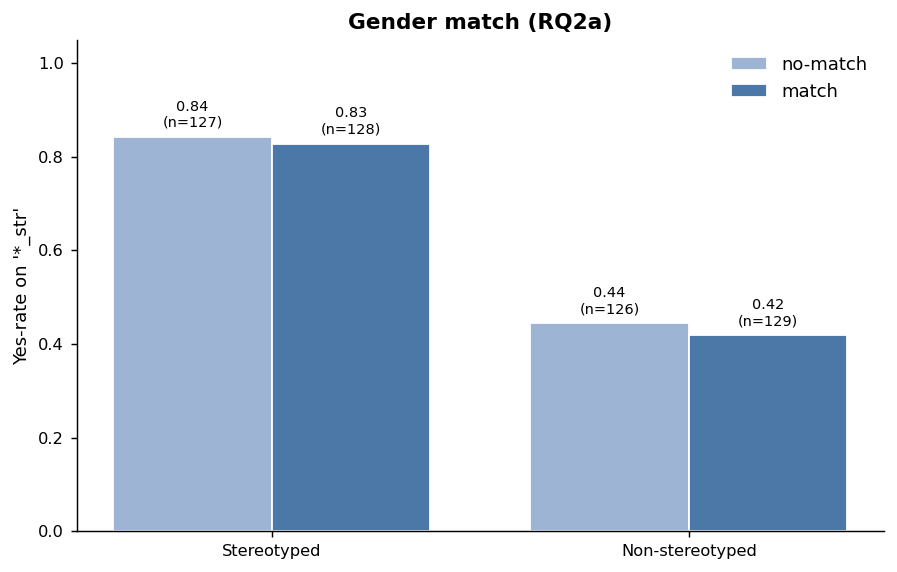

Saved: outputs/figs/fig_match_gender.png


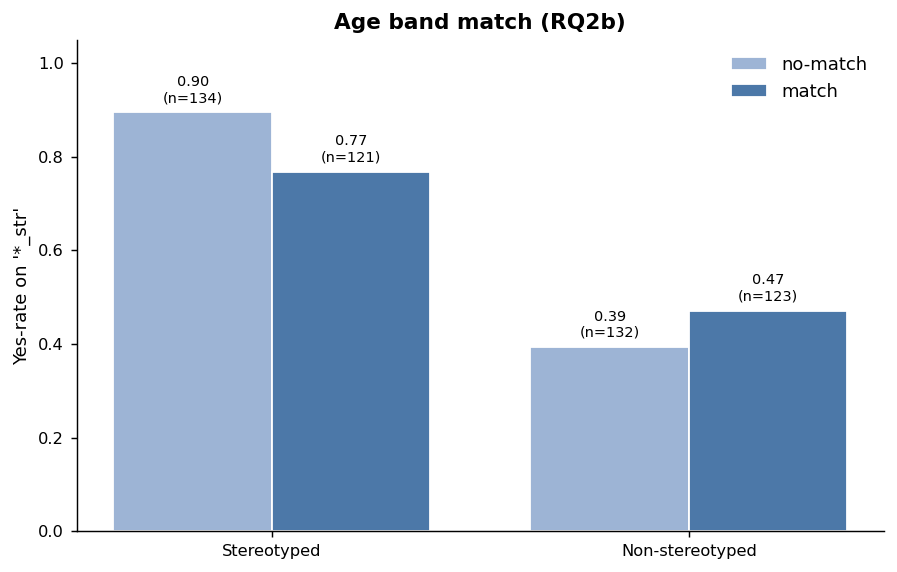

Saved: outputs/figs/fig_match_age.png


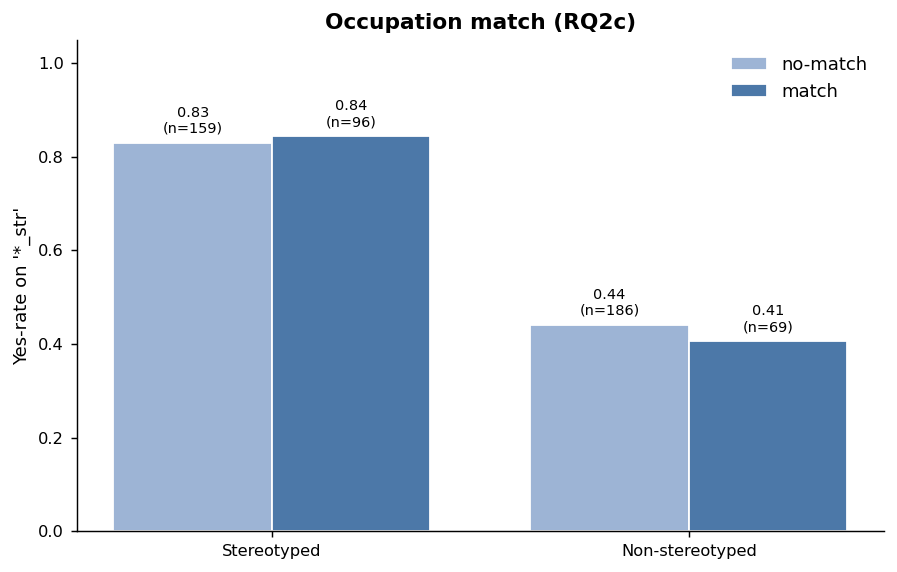

Saved: outputs/figs/fig_match_occupation.png


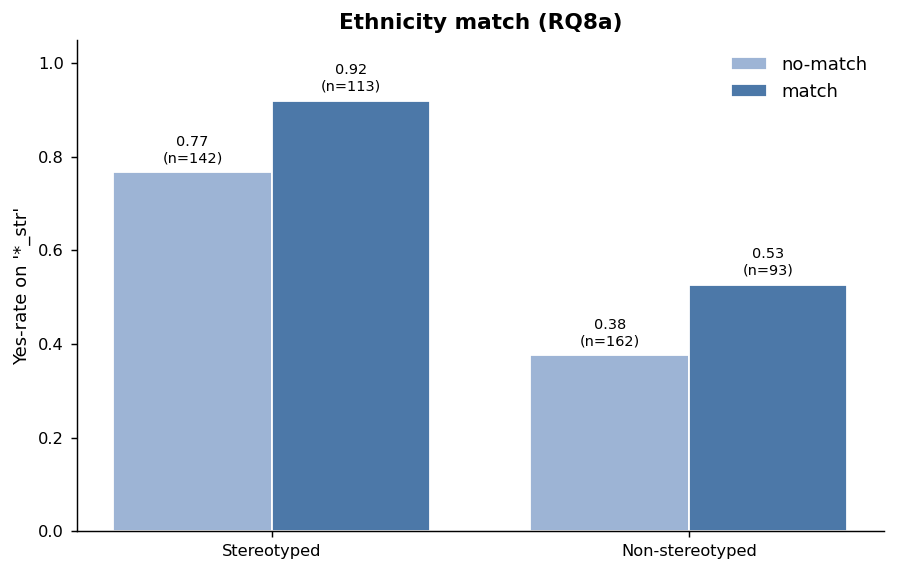

Saved: outputs/figs/fig_match_ethnicity.png


In [45]:
def plot_match_effect(df_in, match_col, title, fname,
                      conditions=("stereo", "non_stereo"),
                      cond_labels=("Stereotyped", "Non-stereotyped")):
    sub = df_in.dropna(subset=[match_col]).copy()
    rates = (sub.groupby(["condition", match_col])["str_yes"]
                .agg(["mean", "count"])
                .reset_index())
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(conditions))
    width = 0.38
    colors = {"no-match": "#9DB4D5", "match": "#4C78A8"}
    for k, m_val in enumerate([0.0, 1.0]):
        ys, ns = [], []
        for c in conditions:
            row = rates[(rates["condition"] == c) & (rates[match_col] == m_val)]
            ys.append(float(row["mean"].iloc[0]) if len(row) else 0)
            ns.append(int(row["count"].iloc[0])  if len(row) else 0)
        label = "match" if m_val == 1.0 else "no-match"
        ax.bar(x + (k - 0.5) * width, ys, width, label=label, color=colors[label], edgecolor="white")
        for xi, y, n in zip(x, ys, ns):
            ax.text(xi + (k - 0.5) * width, y + 0.015, f"{y:.2f}\n(n={n})",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(cond_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Yes-rate on '*_str'")
    ax.set_title(title)
    ax.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    out = FIG_DIR / fname
    plt.savefig(out); plt.show()
    print(f"Saved: {out}")

plot_match_effect(long_df, "gender_match", "Gender match (RQ2a)",       "fig_match_gender.png")
plot_match_effect(long_df, "age_match",    "Age band match (RQ2b)",     "fig_match_age.png")
plot_match_effect(long_df, "occ_match",    "Occupation match (RQ2c)",   "fig_match_occupation.png")
if "eth_match" in long_df.columns:
    plot_match_effect(long_df, "eth_match", "Ethnicity match (RQ8a)",    "fig_match_ethnicity.png")


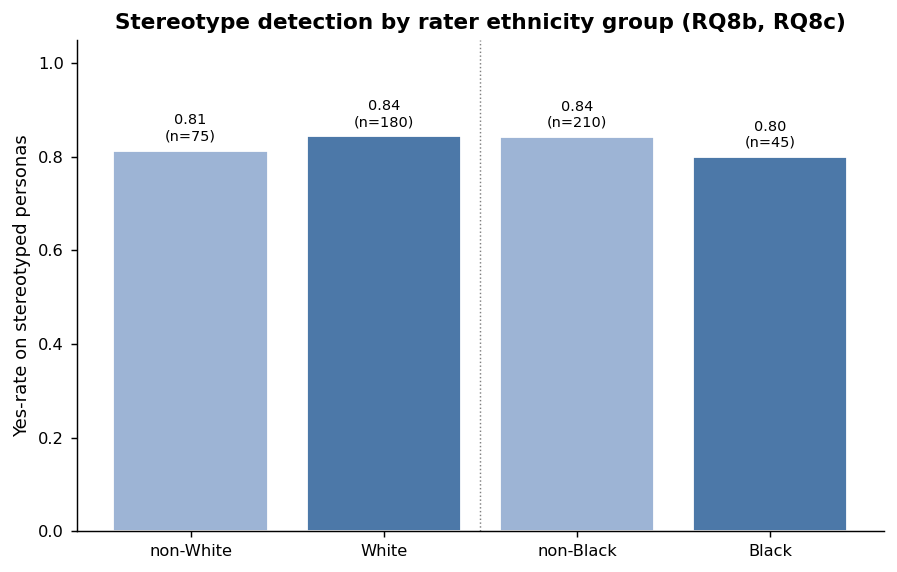

Saved: outputs/figs/fig_ethnicity_group_comparison.png


In [46]:
# Group comparison: White vs non-White, Black vs non-Black (stereotyped only)
if "rater_ethnicity" in long_df.columns:
    ss = long_df[(long_df["condition"] == "stereo") & long_df["rater_ethnicity"].notna()].copy()
    ss["rater_white"] = (ss["rater_ethnicity"] == "Caucasian").astype(int)
    ss["rater_black"] = (ss["rater_ethnicity"] == "Black").astype(int)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    rows = [
        ("non-White", ss.loc[ss["rater_white"] == 0, "str_yes"]),
        ("White",     ss.loc[ss["rater_white"] == 1, "str_yes"]),
        ("non-Black", ss.loc[ss["rater_black"] == 0, "str_yes"]),
        ("Black",     ss.loc[ss["rater_black"] == 1, "str_yes"]),
    ]
    labels = [r[0] for r in rows]
    means  = [r[1].mean()  for r in rows]
    counts = [r[1].count() for r in rows]
    colors = ["#9DB4D5", "#4C78A8", "#9DB4D5", "#4C78A8"]
    ax.bar(range(len(rows)), means, color=colors, edgecolor="white")
    for i, (y, n) in enumerate(zip(means, counts)):
        ax.text(i, y + 0.015, f"{y:.2f}\n(n={n})", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(rows))); ax.set_xticklabels(labels)
    ax.axvline(1.5, color="gray", linestyle=":", linewidth=0.8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Yes-rate on stereotyped personas")
    ax.set_title("Stereotype detection by rater ethnicity group (RQ8b, RQ8c)")
    plt.tight_layout()
    out = FIG_DIR / "fig_ethnicity_group_comparison.png"
    plt.savefig(out); plt.show()
    print(f"Saved: {out}")


## 16. Export the multi-sheet workbook

In [47]:
xlsx_path = OUT_DIR / "persona_stereo_analysis.xlsx"

# Summary tables
summary_per_persona = (long_df
    .groupby(["condition", "persona"])["str_yes"]
    .agg(n="count", yes="sum", yes_rate="mean")
    .reset_index()
    .sort_values(["condition", "yes_rate"], ascending=[True, False]))

summary_per_pid = (long_df
    .groupby(["pid", "condition"])["str_yes"]
    .agg(n="count", yes="sum", yes_rate="mean")
    .reset_index()
    .pivot(index="pid", columns="condition", values=["n", "yes", "yes_rate"]))
summary_per_pid.columns = [f"{a}_{b}" for a, b in summary_per_pid.columns]
summary_per_pid = summary_per_pid.reset_index()

demographics = df[["PROLIFIC_PID", "D1", "D2", "D3", "D5", "D6", "D8", "D9", "D10", "D11", "D12"]].rename(
    columns={"PROLIFIC_PID": "pid"})

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as w:
    long_df.to_excel(w, sheet_name="raw_long",            index=False)
    pid_persona_map_long.to_excel(w, sheet_name="pid_persona_map_long", index=False)
    pid_persona_map_wide.to_excel(w, sheet_name="pid_persona_map_wide", index=False)
    summary_per_persona.to_excel(w, sheet_name="summary_per_persona", index=False)
    summary_per_pid.to_excel(w,     sheet_name="summary_per_pid",     index=False)
    demographics.to_excel(w,        sheet_name="demographics",        index=False)

print(f"Wrote: {xlsx_path}")


Wrote: outputs/persona_stereo_analysis.xlsx


## 17. Plain-text results summary

Writes a flat `results_summary.txt` (no Markdown, no Unicode formatting) summarising every test in the notebook with APA-style result lines. Useful for handing the headline findings to a collaborator who has not opened the notebook.

Sections gate on the presence of relevant columns, so partial runs skip cleanly instead of crashing.


In [48]:
import io
from datetime import datetime

buf = io.StringIO()
def W(*a, **k): print(*a, **k, file=buf)
def H(title, char="="):
    W(); W(char * 78); W(title); W(char * 78)

def lmm_line(model, key, label=None):
    b, se, z, p = model.params[key], model.bse[key], model.tvalues[key], model.pvalues[key]
    sig = "significant" if p < .05 else "non-significant"
    W(f"  {label or key}: b = {b:+.3f}, SE = {se:.3f}, z = {z:.2f}, {apa_p(p)} ({sig})")

# -------- Header --------
H("PERSONA STEREOTYPES EVALUATION — RESULTS SUMMARY")
W(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
W(f"Source data: {CSV_PATH}")
W(f"N participants: {long_df['pid'].nunique()}")
W(f"N persona ratings: {len(long_df)}")

# -------- Sample descriptives --------
H("SAMPLE DESCRIPTIVES", char="-")
age = pd.to_numeric(df["D1"], errors="coerce")
W(f"  Age: M = {age.mean():.1f}, SD = {age.std():.1f}, range {int(age.min())}-{int(age.max())}")
W(f"  Gender: {(df['D2']=='Female').sum()} female, {(df['D2']=='Male').sum()} male")
W(f"  Ethnicity (top): " + ", ".join(f"{k} ({v})" for k, v in df['D12'].value_counts().head(4).items()))

# -------- RQ1 --------
H("RQ1 — MANIPULATION CHECK")
y_s = long_df.loc[long_df.condition=="stereo","str_yes"].sum()
n_s = (long_df.condition=="stereo").sum()
y_u = long_df.loc[long_df.condition=="non_stereo","str_yes"].sum()
n_u = (long_df.condition=="non_stereo").sum()
W(f"  Yes-rate stereo:     {y_s/n_s*100:.1f}% ({y_s}/{n_s})")
W(f"  Yes-rate non-stereo: {y_u/n_u*100:.1f}% ({y_u}/{n_u})")
W(f"  Difference: {(y_s/n_s - y_u/n_u)*100:+.1f} pp")
pp = (y_s+y_u)/(n_s+n_u); se_ = np.sqrt(pp*(1-pp)*(1/n_s+1/n_u))
z = (y_s/n_s - y_u/n_u)/se_; p1 = 1 - stats.norm.cdf(z)
W(f"  Two-proportion z: z = {z:.2f}, {apa_p(p1)} (one-sided)")
per_rater = long_df.groupby(["pid","condition"])["str_yes"].mean().unstack().dropna()
w_ = stats.wilcoxon(per_rater["stereo"], per_rater["non_stereo"], alternative="greater")
W(f"  Wilcoxon paired:   W = {w_.statistic:.1f}, {apa_p(w_.pvalue)}, N = {len(per_rater)}")
m = smf.mixedlm("str_yes ~ C(condition, Treatment(reference='non_stereo'))",
                data=long_df, groups=long_df["pid"]).fit(reml=False)
k = [x for x in m.params.index if "stereo" in x and "Intercept" not in x][0]
lmm_line(m, k, "Condition effect (LMM)")

# -------- RQ2a-c --------
for label, col in [("RQ2a — GENDER MATCH","gender_match"),
                   ("RQ2b — AGE MATCH","age_match"),
                   ("RQ2c — OCCUPATION MATCH","occ_match")]:
    H(label)
    for cond in ["stereo","non_stereo"]:
        sub = long_df[(long_df["condition"]==cond) & long_df[col].notna()]
        if sub.empty or sub[col].nunique()<2:
            W(f"  [{cond}] insufficient variation"); continue
        rates = sub.groupby(col)["str_yes"].agg(["mean","count"])
        W(f"  [{cond}] no-match {rates.loc[0,'mean']:.3f} (n={rates.loc[0,'count']}), "
          f"match {rates.loc[1,'mean']:.3f} (n={rates.loc[1,'count']})")
        m = smf.mixedlm(f"str_yes ~ {col}", data=sub, groups=sub["pid"]).fit(reml=False)
        lmm_line(m, col, f"  {col} effect (LMM, {cond})")

# -------- RQ3 --------
if "cited_age" in long_df.columns:
    H("RQ3 — STEREOTYPE-TYPE ATTRIBUTION")
    dim_cols = ["cited_age","cited_gender","cited_occupation","cited_other"]
    flagged = long_df[long_df["str_yes"]==1]
    W("  Citation rates among flaggers, by condition:")
    for cond, row in flagged.groupby("condition")[dim_cols].mean().round(3).iterrows():
        W(f"    {cond}: " + ", ".join(f"{c.replace('cited_','')} {v:.2f}" for c,v in row.items()))
    ctab = flagged.groupby("condition")[["cited_age","cited_gender","cited_occupation"]].sum()
    chi2, pchi, dof, _ = stats.chi2_contingency(ctab.values)
    W(f"  Chi-square (condition x dimension): chi2({dof}) = {chi2:.2f}, {apa_p(pchi)}")
    if "alignment_jaccard" in long_df.columns:
        al = long_df.groupby("persona")["alignment_jaccard"].mean().dropna()
        W(f"  Mean Jaccard alignment (cited vs intended): {al.mean():.2f}")

# -------- RQ4 --------
if "use_num" in long_df.columns:
    H("RQ4 — USE / RELATABILITY TRADE-OFFS")
    for dv, label in [("use_num","Usefulness"), ("rel_num","Relatability")]:
        by = long_df.groupby("condition")[dv].mean().round(2)
        W(f"  {label}: stereo M = {by.get('stereo',np.nan):.2f}, non-stereo M = {by.get('non_stereo',np.nan):.2f}")
        sub = long_df.dropna(subset=[dv])
        m = smf.mixedlm(f"{dv} ~ C(condition, Treatment(reference='non_stereo'))",
                        data=sub, groups=sub["pid"]).fit(reml=False)
        k = [x for x in m.params.index if "stereo" in x and "Intercept" not in x][0]
        lmm_line(m, k, f"  Condition -> {label}")

# -------- RQ5 --------
if "D11_score" in long_df.columns and "D9_score" in long_df.columns:
    H("RQ5 — INDIVIDUAL DIFFERENCES (D9, D11)")
    for pred in ["D11_score","D9_score"]:
        sub = long_df.dropna(subset=[pred,"str_yes"]).copy()
        sub["cond_bin"] = (sub["condition"]=="stereo").astype(int)
        m = smf.mixedlm(f"str_yes ~ cond_bin * {pred}", data=sub, groups=sub["pid"]).fit(reml=False)
        W(f"  {pred}:")
        lmm_line(m, pred,                  f"    Main effect")
        lmm_line(m, f"cond_bin:{pred}",    f"    Condition x {pred}")

# -------- RQ6 --------
if "baseline_yes" in long_df.columns:
    H("RQ6 — AGE-MATCH DIAGNOSTIC")
    ss = long_df[(long_df["condition"]=="stereo") &
                 long_df["age_match"].notna() &
                 long_df["baseline_yes"].notna()].copy()
    m = smf.mixedlm("str_yes ~ age_match + baseline_yes", data=ss, groups=ss["pid"]).fit(reml=False)
    lmm_line(m, "age_match",    "  age_match (controlling for rater baseline Yes-rate)")
    lmm_line(m, "baseline_yes", "  baseline_yes covariate")
    W("  Per-persona age-match (stereo only):")
    for p in ["bernie","sofia","caroline","james","ray","aisha"]:
        s = long_df[(long_df["persona"]==p) & long_df["age_match"].notna()]
        if s["age_match"].nunique()<2:
            W(f"    {p}: insufficient variation"); continue
        r = s.groupby("age_match")["str_yes"].agg(["mean","count"])
        diff = r.loc[1,"mean"] - r.loc[0,"mean"]
        W(f"    {p}: no-match {r.loc[0,'mean']:.2f} (n={r.loc[0,'count']}), "
          f"match {r.loc[1,'mean']:.2f} (n={r.loc[1,'count']}), diff = {diff:+.2f}")

# -------- RQ7 --------
if "img_yes" in long_df.columns:
    H("RQ7 — IMAGE vs DESCRIPTION CONGRUENCE")
    yi_s = long_df.loc[long_df.condition=="stereo","img_yes"].sum()
    ni_s = long_df.loc[long_df.condition=="stereo","img_yes"].notna().sum()
    yi_u = long_df.loc[long_df.condition=="non_stereo","img_yes"].sum()
    ni_u = long_df.loc[long_df.condition=="non_stereo","img_yes"].notna().sum()
    W(f"  Image Yes-rate stereo:     {yi_s/ni_s*100:.1f}%")
    W(f"  Image Yes-rate non-stereo: {yi_u/ni_u*100:.1f}%")
    both = long_df.dropna(subset=["img_yes","str_yes"])
    chi2, pchi, dof, _ = stats.chi2_contingency(pd.crosstab(both["img_yes"], both["str_yes"]).values)
    phi = np.sqrt(chi2/len(both))
    W(f"  img_yes x str_yes association: chi2({dof}) = {chi2:.2f}, {apa_p(pchi)}, phi = {phi:.2f}")

# -------- RQ8 --------
if "eth_match" in long_df.columns:
    H("RQ8 — ETHNICITY")
    W("  RQ8a — Ethnicity match:")
    for cond in ["stereo","non_stereo"]:
        sub = long_df[(long_df["condition"]==cond) & long_df["eth_match"].notna()]
        if sub.empty or sub["eth_match"].nunique()<2:
            W(f"    [{cond}] insufficient variation"); continue
        r = sub.groupby("eth_match")["str_yes"].agg(["mean","count"])
        W(f"    [{cond}] no-match {r.loc[0,'mean']:.3f} (n={r.loc[0,'count']}), "
          f"match {r.loc[1,'mean']:.3f} (n={r.loc[1,'count']})")
        m = smf.mixedlm("str_yes ~ eth_match", data=sub, groups=sub["pid"]).fit(reml=False)
        lmm_line(m, "eth_match", f"    eth_match (LMM, {cond})")
    if "rater_ethnicity" in long_df.columns:
        ss = long_df[(long_df["condition"]=="stereo") & long_df["rater_ethnicity"].notna()].copy()
        ss["rater_white"] = (ss["rater_ethnicity"]=="Caucasian").astype(int)
        ss["rater_black"] = (ss["rater_ethnicity"]=="Black").astype(int)
        W("  RQ8b — White vs non-White (stereo):")
        m = smf.mixedlm("str_yes ~ rater_white", data=ss, groups=ss["pid"]).fit(reml=False)
        lmm_line(m, "rater_white", "    rater_white")
        W("  RQ8c — Black vs non-Black (stereo):")
        m = smf.mixedlm("str_yes ~ rater_black", data=ss, groups=ss["pid"]).fit(reml=False)
        lmm_line(m, "rater_black", "    rater_black")

# -------- Write --------
H("END OF SUMMARY")
out_path = OUT_DIR / "results_summary.txt"
out_path.write_text(buf.getvalue())
print(f"Saved: {out_path}")
print(f"Length: {len(buf.getvalue())} chars, {buf.getvalue().count(chr(10))} lines")
print("\nPreview (first 60 lines):")
print("\n".join(buf.getvalue().splitlines()[:60]))


Saved: outputs/results_summary.txt
Length: 6309 chars, 113 lines

Preview (first 60 lines):

PERSONA STEREOTYPES EVALUATION — RESULTS SUMMARY
Generated: 2026-05-23 12:09
Source data: https://raw.githubusercontent.com/danial-amin/persona-papers/refs/heads/main/Persona%20Stereotypes%20Evaluation-2026%20-%20Cleaned-v1.csv
N participants: 85
N persona ratings: 510

------------------------------------------------------------------------------
SAMPLE DESCRIPTIVES
------------------------------------------------------------------------------
  Age: M = 37.2, SD = 10.7, range 21-77
  Gender: 38 female, 47 male
  Ethnicity (top): Caucasian (58), Black or African American (13), Asian (7), Prefer not to say (3)

RQ1 — MANIPULATION CHECK
  Yes-rate stereo:     83.5% (213/255)
  Yes-rate non-stereo: 43.1% (110/255)
  Difference: +40.4 pp
  Two-proportion z: z = 9.46, p < .001 (one-sided)
  Wilcoxon paired:   W = 1912.0, p < .001, N = 85
  Condition effect (LMM): b = +0.404, SE = 0.037, z = 10.97, 